In [6]:
import pandas as pd

# Carregar datasets
visits = pd.read_csv('/datasets/visits_log_us.csv')
orders = pd.read_csv('/datasets/orders_log_us.csv')
costs = pd.read_csv('/datasets/costs_us.csv')

# Converter colunas de datas para datetime
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
costs['dt'] = pd.to_datetime(costs['dt'])


In [18]:
# Usuários ativos por dia
dau = visits.groupby(visits['Start Ts'].dt.date)['Uid'].nunique()

# Usuários ativos por semana
wau = visits.groupby(visits['Start Ts'].dt.to_period('W'))['Uid'].nunique()

# Usuários ativos por mês
mau = visits.groupby(visits['Start Ts'].dt.to_period('M'))['Uid'].nunique()


DAU:
 Start Ts
2017-06-01    605
2017-06-02    608
2017-06-03    445
2017-06-04    476
2017-06-05    820
Name: Uid, dtype: int64
WAU:
 Start Ts
2017-05-29/2017-06-04    2021
2017-06-05/2017-06-11    4129
2017-06-12/2017-06-18    2812
2017-06-19/2017-06-25    2878
2017-06-26/2017-07-02    3064
Freq: W-SUN, Name: Uid, dtype: int64
MAU:
 Start Ts
2017-06    13259
2017-07    14183
2017-08    11631
2017-09    18975
2017-10    29692
Freq: M, Name: Uid, dtype: int64


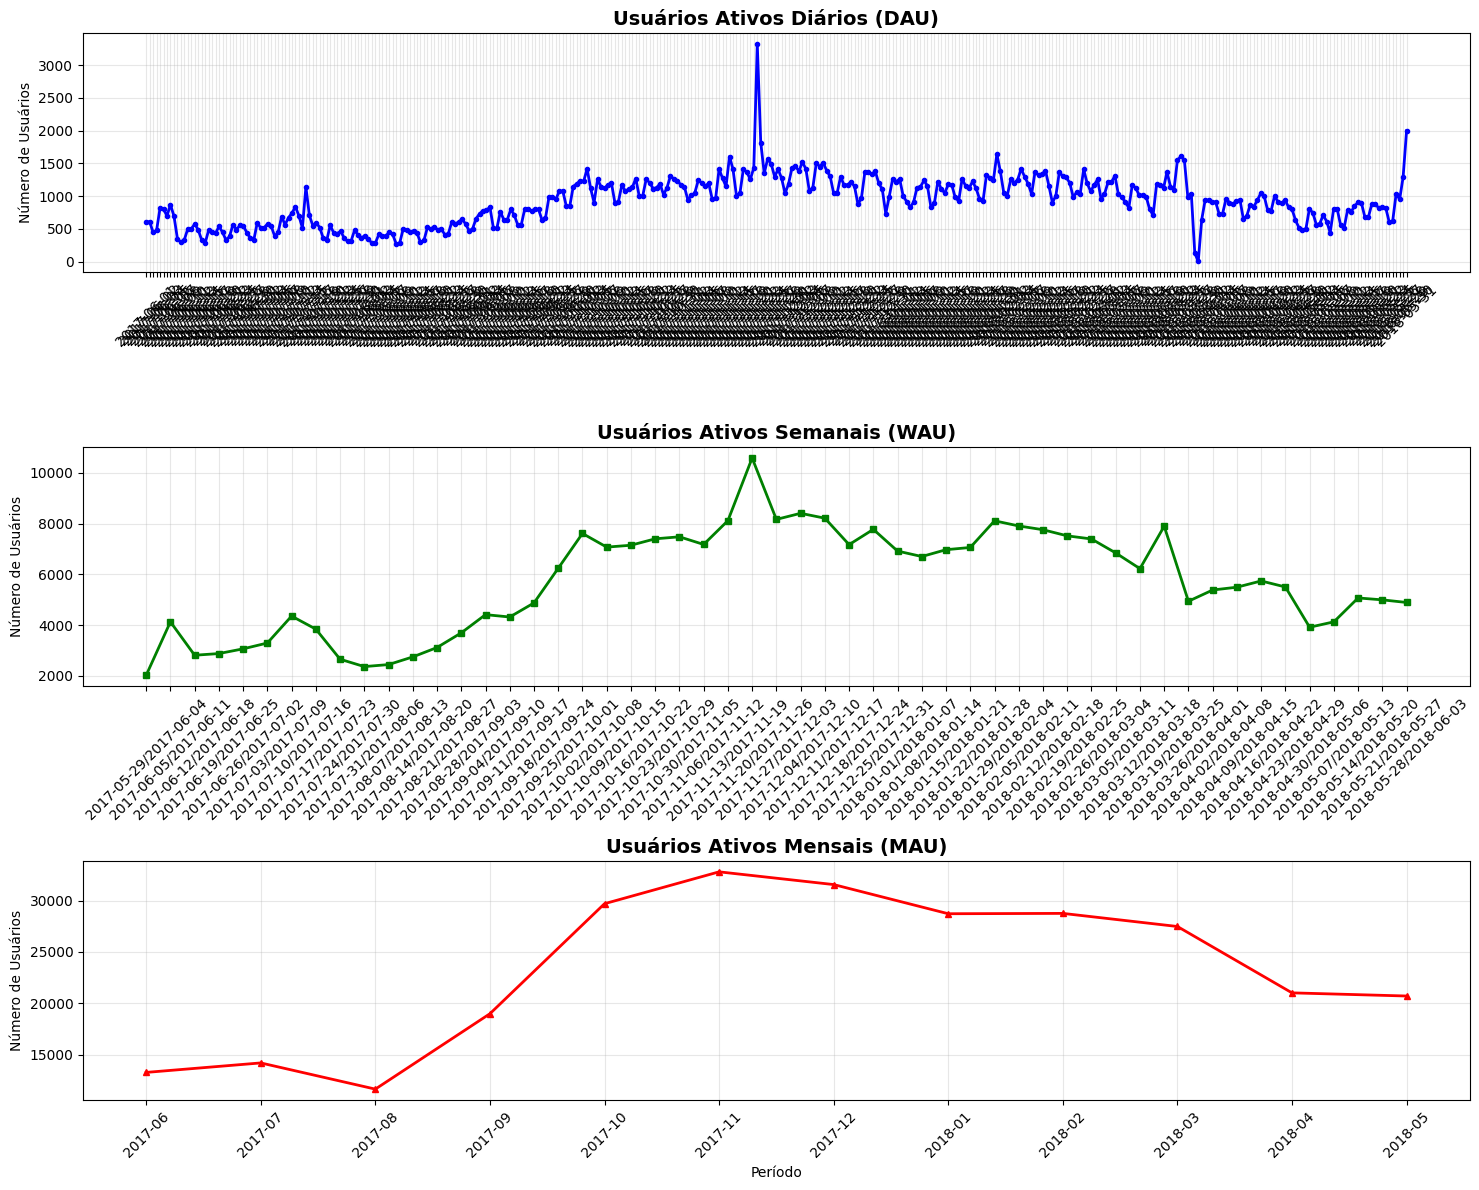

In [19]:
print("DAU:\n", dau.head())
print("WAU:\n", wau.head())
print("MAU:\n", mau.head())



import matplotlib.pyplot as plt

# Criar subplots para melhor visualização
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# DAU - Gráfico diário
ax1.plot(dau.index.astype(str), dau.values, color='blue', linewidth=2, marker='o', markersize=3)
ax1.set_title('Usuários Ativos Diários (DAU)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Usuários')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# WAU - Gráfico semanal  
ax2.plot(wau.index.astype(str), wau.values, color='green', linewidth=2, marker='s', markersize=4)
ax2.set_title('Usuários Ativos Semanais (WAU)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Número de Usuários')
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# MAU - Gráfico mensal
ax3.plot(mau.index.astype(str), mau.values, color='red', linewidth=2, marker='^', markersize=5)
ax3.set_title('Usuários Ativos Mensais (MAU)', fontsize=14, fontweight='bold')
ax3.set_ylabel('Número de Usuários')
ax3.set_xlabel('Período')
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Duração das sessões
visits['session_duration'] = (visits['End Ts'] - visits['Start Ts']).dt.total_seconds() / 60  # em minutos
avg_session_duration = visits['session_duration'].mean()

In [24]:

# Agrupar sessões por usuário e ordenar pelas datas
user_sessions = visits.groupby('Uid')['Start Ts'].apply(list)

# Calcular o intervalo médio entre sessões de cada usuário
import numpy as np

def avg_return_interval(session_list):
    if len(session_list) < 2:
        return np.nan
    session_list = sorted(session_list)
    diffs = np.diff(session_list)
    return np.mean(diffs).days  # intervalo médio em dias

user_sessions_interval = user_sessions.apply(avg_return_interval)

# Frequência média de retorno dos usuários
avg_return = user_sessions_interval.mean()
print("Em média, os usuários retornam a cada", round(avg_return, 2), "dias")


Em média, os usuários retornam a cada 40.67 dias


NameError: name 'sessions_per_day' is not defined

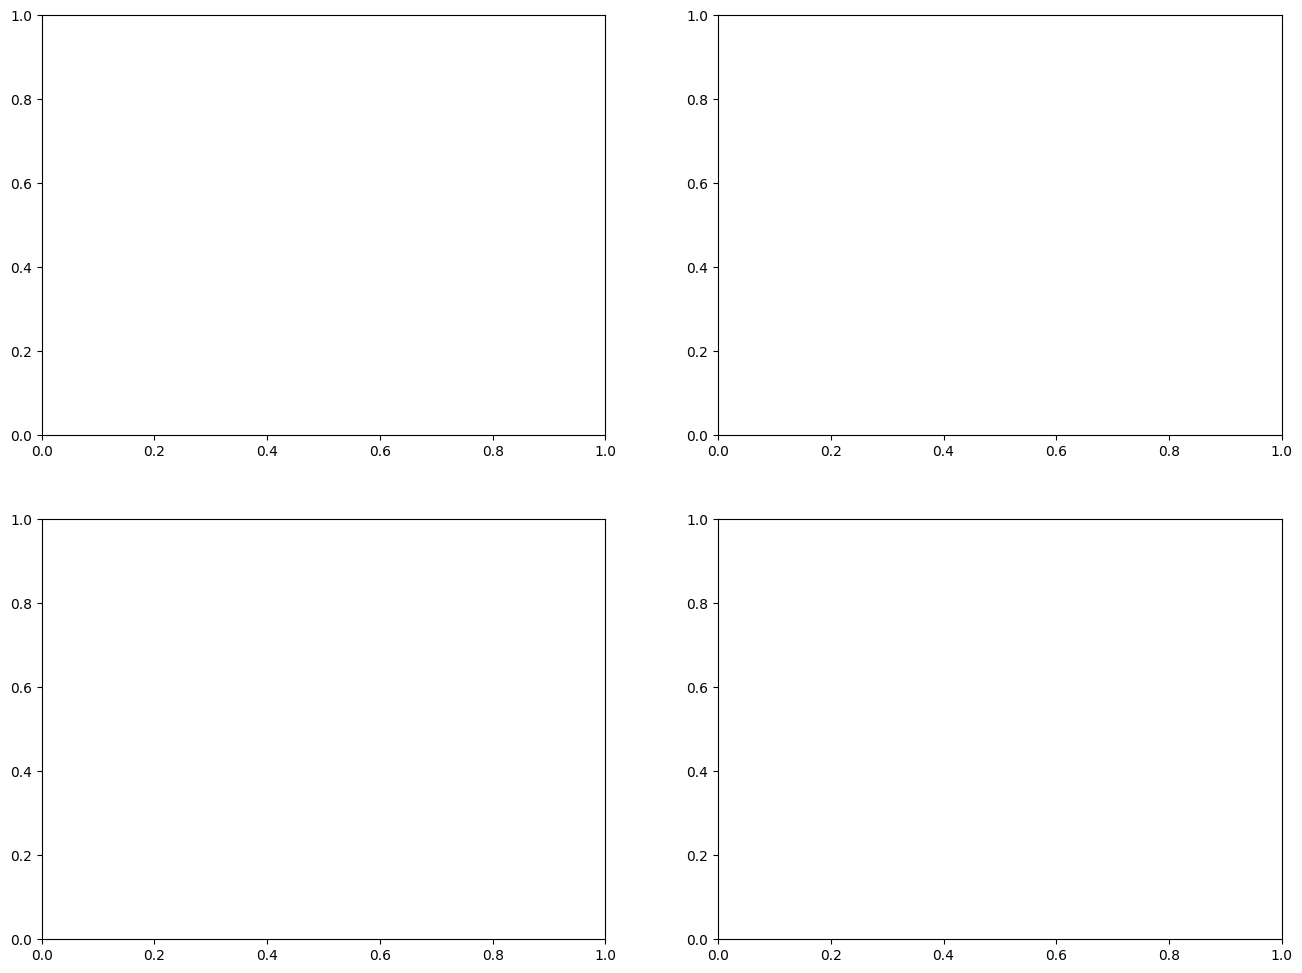

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Criar figura com subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico de linha - Sessões por dia ao longo do tempo
ax1.plot(sessions_per_day.index, sessions_per_day.values, color='purple', linewidth=2, alpha=0.8)
ax1.set_title('Número de Sessões por Dia', fontsize=14, fontweight='bold')
ax1.set_ylabel('Número de Sessões')
ax1.set_xlabel('Data')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Histograma - Distribuição do número de sessões
ax2.hist(sessions_per_day.values, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax2.set_title('Distribuição do Número de Sessões por Dia', fontsize=14, fontweight='bold')
ax2.set_xlabel('Número de Sessões')
ax2.set_ylabel('Frequência (dias)')
ax2.grid(True, alpha=0.3)

# 3. Box plot - Estatísticas das sessões
ax3.boxplot(sessions_per_day.values, patch_artist=True, 
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax3.set_title('Estatísticas das Sessões por Dia', fontsize=14, fontweight='bold')
ax3.set_ylabel('Número de Sessões')
ax3.grid(True, alpha=0.3)

# 4. Sessões por dia da semana
sessions_by_weekday = visits.groupby(visits['Start Ts'].dt.day_name()).size()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sessions_by_weekday = sessions_by_weekday.reindex(weekday_order)

ax4.bar(range(len(sessions_by_weekday)), sessions_by_weekday.values, 
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'])
ax4.set_title('Sessões por Dia da Semana', fontsize=14, fontweight='bold')
ax4.set_xlabel('Dia da Semana')
ax4.set_ylabel('Total de Sessões')
ax4.set_xticks(range(len(sessions_by_weekday)))
ax4.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print("📊 ESTATÍSTICAS DAS SESSÕES POR DIA:")
print(f"• Média diária: {sessions_per_day.mean():.1f} sessões")
print(f"• Mediana: {sessions_per_day.median():.1f} sessões")
print(f"• Máximo: {sessions_per_day.max()} sessões")
print(f"• Mínimo: {sessions_per_day.min()} sessões")





In [ ]:
# Teste simples com os dados de sessões
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(sessions_per_day.index, sessions_per_day.values, color='purple', linewidth=2)
plt.title('Sessões por Dia - Teste Simples')
plt.ylabel('Número de Sessões')
plt.xlabel('Data')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dados carregados: {len(sessions_per_day)} dias")
print(f"Primeira data: {sessions_per_day.index[0]}")
print(f"Última data: {sessions_per_day.index[-1]}")

<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- tudo certo até aqui

</div>

In [ ]:
# Teste simples do matplotlib
import matplotlib.pyplot as plt

# Teste básico
plt.figure(figsize=(8, 4))
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])
plt.title('Teste do Matplotlib')
plt.show()

# Verificar se temos dados
print(f"Temos {len(sessions_per_day)} dias de dados")
print(f"Primeiros 5 valores: {sessions_per_day.head()}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Versão corrigida - começando com 2 gráficos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de linha - Sessões por dia
ax1.plot(sessions_per_day.index, sessions_per_day.values, color='purple', linewidth=2)
ax1.set_title('Sessões por Dia ao Longo do Tempo')
ax1.set_ylabel('Número de Sessões')
ax1.set_xlabel('Data')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Histograma - Distribuição das sessões
ax2.hist(sessions_per_day.values, bins=25, color='orange', alpha=0.7, edgecolor='black')
ax2.set_title('Distribuição das Sessões por Dia')
ax2.set_xlabel('Número de Sessões')
ax2.set_ylabel('Frequência (dias)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas básicas
print(" ESTATÍSTICAS DAS SESSÕES:")
print(f"• Média: {sessions_per_day.mean():.1f} sessões/dia")
print(f"• Mediana: {sessions_per_day.median():.1f} sessões/dia")
print(f"• Máximo: {sessions_per_day.max()} sessões")
print(f"• Mínimo: {sessions_per_day.min()} sessões")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Versão completa - 4 gráficos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico de linha - Sessões por dia
ax1.plot(sessions_per_day.index, sessions_per_day.values, color='purple', linewidth=2)
ax1.set_title('Sessões por Dia ao Longo do Tempo')
ax1.set_ylabel('Número de Sessões')
ax1.set_xlabel('Data')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Histograma - Distribuição das sessões
ax2.hist(sessions_per_day.values, bins=25, color='orange', alpha=0.7, edgecolor='black')
ax2.set_title('Distribuição das Sessões por Dia')
ax2.set_xlabel('Número de Sessões')
ax2.set_ylabel('Frequência (dias)')
ax2.grid(True, alpha=0.3)

# 3. Box plot - Estatísticas das sessões
ax3.boxplot(sessions_per_day.values, patch_artist=True,
           boxprops=dict(facecolor='lightblue', alpha=0.7))
ax3.set_title('Box Plot - Estatísticas das Sessões')
ax3.set_ylabel('Número de Sessões')
ax3.grid(True, alpha=0.3)

# 4. Sessões por dia da semana
sessions_by_weekday = visits.groupby(visits['Start Ts'].dt.day_name()).size()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sessions_by_weekday = sessions_by_weekday.reindex(weekday_order)

ax4.bar(range(len(sessions_by_weekday)), sessions_by_weekday.values,
        color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8'])
ax4.set_title('Sessões por Dia da Semana')
ax4.set_xlabel('Dia da Semana')
ax4.set_ylabel('Total de Sessões')
ax4.set_xticks(range(len(sessions_by_weekday)))
ax4.set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print(" ESTATÍSTICAS DAS SESSÕES POR DIA:")
print(f"• Média diária: {sessions_per_day.mean():.1f} sessões")
print(f"• Mediana: {sessions_per_day.median():.1f} sessões")
print(f"• Máximo: {sessions_per_day.max()} sessões")
print(f"• Mínimo: {sessions_per_day.min()}sessões")

In [13]:
# Estatísticas da duração das sessões
print("📊 ESTATÍSTICAS DA DURAÇÃO DAS SESSÕES:")
print(visits['session_duration'].describe())
print(f"\nDuração média: {visits['session_duration'].mean():.2f} minutos")
print(f"Duração mediana: {visits['session_duration'].median():.2f} minutos")

📊 ESTATÍSTICAS DA DURAÇÃO DAS SESSÕES:
count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration, dtype: float64

Duração média: 10.72 minutos
Duração mediana: 5.00 minutos


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Preparar dados temporais mais detalhados
visits['date'] = visits['Start Ts'].dt.date
visits['month'] = visits['Start Ts'].dt.month
visits['week'] = visits['Start Ts'].dt.isocalendar().week
visits['weekday'] = visits['Start Ts'].dt.day_name()
visits['hour'] = visits['Start Ts'].dt.hour

# 1. TENDÊNCIAS MENSAIS
monthly_sessions = visits.groupby(visits['Start Ts'].dt.to_period('M')).size()
monthly_users = visits.groupby(visits['Start Ts'].dt.to_period('M'))['Uid'].nunique()
monthly_avg_duration = visits.groupby(visits['Start Ts'].dt.to_period('M'))['session_duration'].mean()

print(" ANÁLISE DE TENDÊNCIAS TEMPORAIS")
print("=" * 50)
print(f"Período analisado: {visits['Start Ts'].min().date()} a {visits['Start Ts'].max().date()}")
print(f"Total de sessões: {len(visits):,}")
print(f"Usuários únicos: {visits['Uid'].nunique():,}")

 ANÁLISE DE TENDÊNCIAS TEMPORAIS
Período analisado: 2017-06-01 a 2018-05-31
Total de sessões: 359,400
Usuários únicos: 228,169


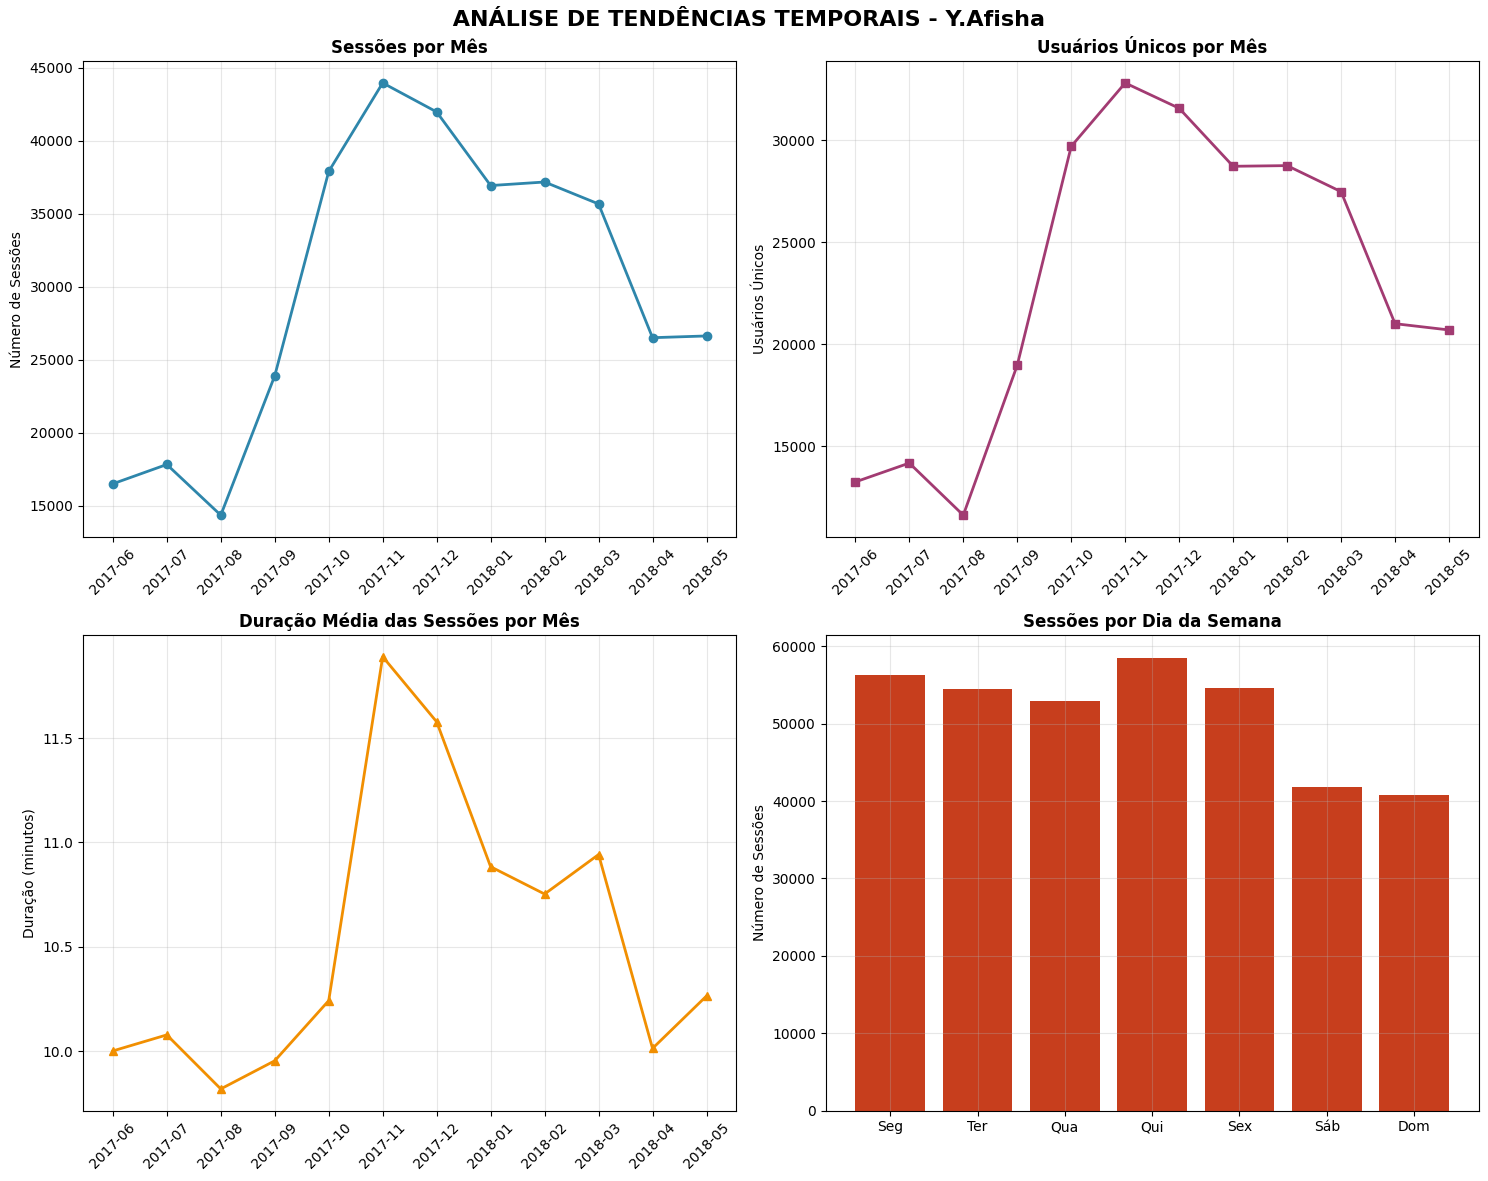

• Mínimo: 1 sessões


In [15]:
# Criar figura com múltiplos subplots para análise temporal
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(' ANÁLISE DE TENDÊNCIAS TEMPORAIS - Y.Afisha', fontsize=16, fontweight='bold')

# 1. Tendência Mensal de Sessões
axes[0,0].plot(monthly_sessions.index.astype(str), monthly_sessions.values, 
               marker='o', linewidth=2, markersize=6, color='#2E86AB')
axes[0,0].set_title('Sessões por Mês', fontweight='bold')
axes[0,0].set_ylabel('Número de Sessões')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Tendência Mensal de Usuários Únicos
axes[0,1].plot(monthly_users.index.astype(str), monthly_users.values, 
               marker='s', linewidth=2, markersize=6, color='#A23B72')
axes[0,1].set_title('Usuários Únicos por Mês', fontweight='bold')
axes[0,1].set_ylabel('Usuários Únicos')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Duração Média das Sessões por Mês
axes[1,0].plot(monthly_avg_duration.index.astype(str), monthly_avg_duration.values, 
               marker='^', linewidth=2, markersize=6, color='#F18F01')
axes[1,0].set_title('Duração Média das Sessões por Mês', fontweight='bold')
axes[1,0].set_ylabel('Duração (minutos)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].grid(True, alpha=0.3)

# 4. Sessões por Dia da Semana
weekday_sessions = visits.groupby('weekday').size().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
axes[1,1].bar(range(len(weekday_sessions)), weekday_sessions.values, color='#C73E1D')
axes[1,1].set_title('Sessões por Dia da Semana', fontweight='bold')
axes[1,1].set_ylabel('Número de Sessões')
axes[1,1].set_xticks(range(len(weekday_sessions)))
axes[1,1].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Versão corrigida da última linha:
print(f"• Mínimo: {sessions_per_day.min()} sessões")  # Adicionado ()

<div class="alert alert-block alert-warning">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- me parece que alguams análises estão  repetidas

</div>

In [3]:
# Verificar se as variáveis existem
try:
    print("✅ visits carregado:", len(visits), "registros")
    print("✅ orders carregado:", len(orders), "registros") 
    print("✅ costs carregado:", len(costs), "registros")
    print("Colunas do visits:", visits.columns.tolist())
except NameError as e:
    print("❌ Erro:", e)
    print("Execute a célula 2 primeiro!")

#COM QUE FREQUÊNCIA OS USUÁRIOS VOLTAM.
#Determinando o mês de aquisição de cada usuário (primeira sessão)
user_acquisition = visits.groupby('Uid')['Start Ts'].min().reset_index()
user_acquisition.columns = ['Uid', 'first_session']
user_acquisition['acquisition_month'] = user_acquisition['first_session'].dt.to_period('M')

print("Primeiros usuários por mês de aquisição:")
print(user_acquisition['acquisition_month'].value_counts().sort_index())


✅ visits carregado: 359400 registros
✅ orders carregado: 50415 registros
✅ costs carregado: 2542 registros
Colunas do visits: ['Device', 'End Ts', 'Source Id', 'Start Ts', 'Uid']
Primeiros usuários por mês de aquisição:
2017-06    13259
2017-07    13140
2017-08    10181
2017-09    16704
2017-10    25977
2017-11    27248
2017-12    25268
2018-01    22624
2018-02    22197
2018-03    20589
2018-04    15709
2018-05    15273
Freq: M, Name: acquisition_month, dtype: int64


In [16]:
visits['session_month'] = visits['Start Ts'].dt.to_period('M')
# Fazer merge para adicionar acquisition_month ao DataFrame visits
visits = visits.merge(user_acquisition[['Uid', 'acquisition_month']], on='Uid', how='left')

# Recriar user_acquisition
user_acquisition = visits.groupby('Uid')['Start Ts'].min().reset_index()
user_acquisition.columns = ['Uid', 'first_session']
user_acquisition['acquisition_month'] = user_acquisition['first_session'].dt.to_period('M')
print("user_acquisition criado com sucesso!")
print(user_acquisition.head())

# # Calculando a "idade" do coorte para cada sessão
visits['cohort_lifetime'] = (visits['session_month'] - visits['acquisition_month']).apply(lambda x: x.n)





user_acquisition criado com sucesso!
               Uid       first_session acquisition_month
0   11863502262781 2018-03-01 17:27:00           2018-03
1   49537067089222 2018-02-06 15:55:00           2018-02
2  297729379853735 2017-06-07 18:47:00           2017-06
3  313578113262317 2017-09-18 22:49:00           2017-09
4  325320750514679 2017-09-30 14:29:00           2017-09


In [20]:
# # Tabela de coortes (pivot table)
cohorts = visits.groupby(['acquisition_month', 'cohort_lifetime'])['Uid'].nunique().reset_index()
cohorts_pivot = cohorts.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='Uid')

In [21]:
# Imprimir a tabela de coortes
print("TABELA DE COORTES - Y.AFISHA")
print("=" * 60)
print("\nTabela mostra quantos usuários únicos retornaram em cada período:")
print("- Linhas: Mês de aquisição (quando o usuário chegou pela primeira vez)")
print("- Colunas: Período de vida do coorte (0 = primeiro mês, 1 = segundo mês, etc.)")
print("- Valores: Número de usuários únicos ativos naquele período\n")

# Exibir a tabela
print(cohorts_pivot)

TABELA DE COORTES - Y.AFISHA

Tabela mostra quantos usuários únicos retornaram em cada período:
- Linhas: Mês de aquisição (quando o usuário chegou pela primeira vez)
- Colunas: Período de vida do coorte (0 = primeiro mês, 1 = segundo mês, etc.)
- Valores: Número de usuários únicos ativos naquele período

cohort_lifetime         0       1       2       3      4      5      6   \
acquisition_month                                                         
2017-06            13259.0  1043.0   713.0   814.0  909.0  947.0  809.0   
2017-07            13140.0   737.0   674.0   738.0  765.0  633.0  596.0   
2017-08            10181.0   783.0   640.0   639.0  510.0  448.0  370.0   
2017-09            16704.0  1428.0  1156.0   847.0  658.0  632.0  599.0   
2017-10            25977.0  2042.0  1357.0  1012.0  890.0  837.0  555.0   
2017-11            27248.0  2133.0  1202.0  1054.0  919.0  638.0  594.0   
2017-12            25268.0  1410.0   960.0   786.0  512.0  481.0    NaN   
2018-01           

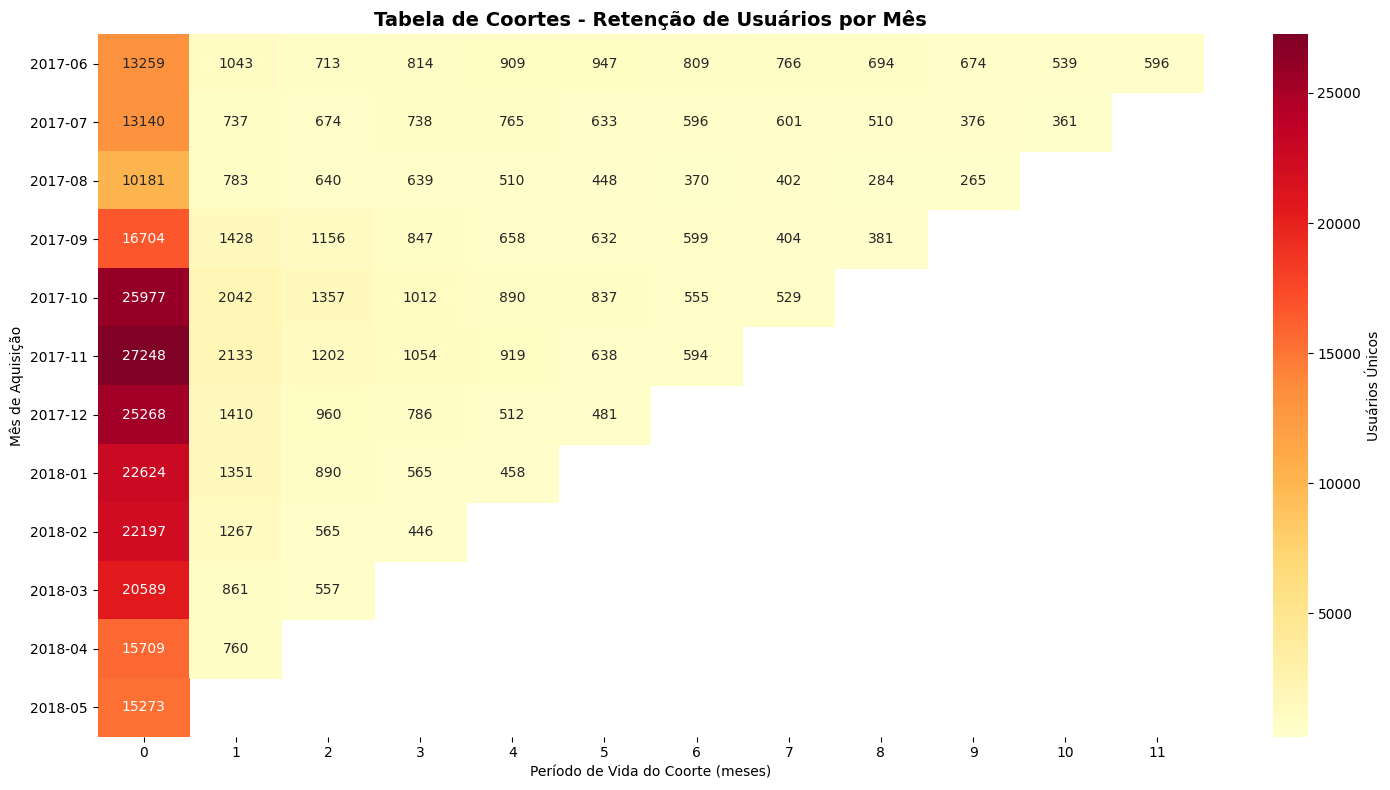

In [22]:
# Versão mais visual da tabela de coortes
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.heatmap(cohorts_pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Usuários Únicos'})
plt.title('Tabela de Coortes - Retenção de Usuários por Mês', 
          fontsize=14, fontweight='bold')
plt.xlabel('Período de Vida do Coorte (meses)')
plt.ylabel('Mês de Aquisição')
plt.tight_layout()
plt.show()

In [23]:

# # Calculando a retenção em percentual
cohort_size = cohorts_pivot.iloc[:, 0]
retention_matrix = cohorts_pivot.divide(cohort_size, axis=0)

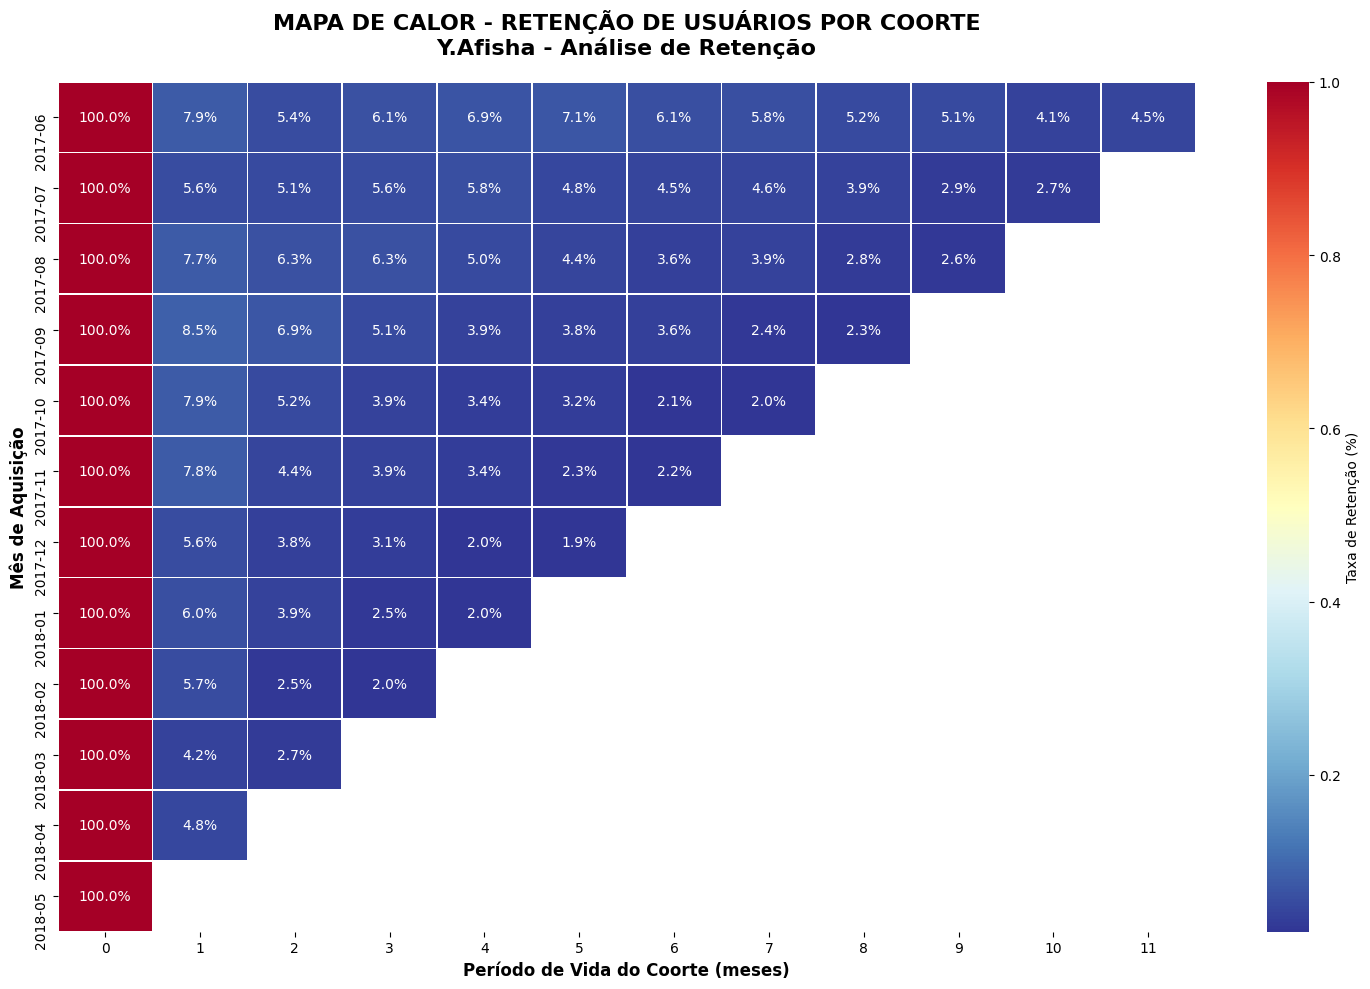

 ESTATÍSTICAS DE RETENÇÃO:
• Retenção média no 1º mês: 6.5%


In [24]:
# ## MAPA DE CALOR DE RETENÇÃO
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o tamanho da figura
plt.figure(figsize=(15, 10))

# Criar o heatmap de retenção
sns.heatmap(retention_matrix, 
            annot=True,           # Mostrar valores nas células
            fmt='.1%',            # Formato percentual com 1 casa decimal
            cmap='RdYlBu_r',      # Paleta de cores (vermelho-amarelo-azul invertida)
            cbar_kws={'label': 'Taxa de Retenção (%)'}, 
            linewidths=0.5,       # Linhas entre células
            square=False)         # Células não quadradas

# Personalizar o gráfico
plt.title('MAPA DE CALOR - RETENÇÃO DE USUÁRIOS POR COORTE\nY.Afisha - Análise de Retenção', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Período de Vida do Coorte (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Mês de Aquisição', fontsize=12, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

# Estatísticas da retenção
print(" ESTATÍSTICAS DE RETENÇÃO:")
print("=" * 50)
print(f"• Retenção média no 1º mês: {retention_matrix.iloc[:, 1].mean():.1%}")

In [33]:
# Adicione esta linha antes de usar sessions_per_day
sessions_per_day = visits.groupby(visits['Start Ts'].dt.date).size()

# # --- Quando as pessoas começam a comprar?

# # Encontrando a primeira visita de cada usuário
first_visit = visits.groupby('Uid')['Start Ts'].min().reset_index()
first_visit.columns = ['Uid', 'first_visit_ts']

# Definir sessions_per_day
sessions_per_day = visits.groupby(visits['Start Ts'].dt.date).size()
print(f"sessions_per_day criado com {len(sessions_per_day)} registros")

sessions_per_day criado com 364 registros


In [39]:

# # Encontrando a primeira compra de cada usuário
first_order = orders.groupby('Uid')['Buy Ts'].min().reset_index()
first_order.columns = ['Uid', 'first_buy_ts']
print(orders.columns.tolist())
print("Colunas do visits:", visits.columns.tolist())
print("Colunas do orders:", orders.columns.tolist())
print("Colunas do costs:", costs.columns.tolist())

['Buy Ts', 'Revenue', 'Uid']
Colunas do visits: ['Device', 'End Ts', 'Source Id', 'Start Ts', 'Uid', 'session_month', 'acquisition_month_x', 'cohort_lifetime', 'acquisition_month_y', 'acquisition_month_x', 'acquisition_month_y', 'acquisition_month_x', 'acquisition_month_y', 'acquisition_month']
Colunas do orders: ['Buy Ts', 'Revenue', 'Uid']
Colunas do costs: ['source_id', 'dt', 'costs']


In [16]:
# Usuários únicos que fizeram pelo menos uma compra
buyers = orders['Uid'].nunique()
print("Número de usuários que compraram:", buyers)

Número de usuários que compraram: 36523


In [17]:
# Total de usuários únicos (visitantes)
total_users = visits['Uid'].nunique()

# Taxa de conversão
conversion_rate = (buyers / total_users) * 100

print(f"Total de usuários: {total_users}")
print(f"Usuários que compraram: {buyers}")
print(f"Taxa de conversão: {conversion_rate:.2f}%")


total_users = visits['Uid'].nunique()

# Taxa de conversão
conversion_rate = (buyers / total_users) * 100

Total de usuários: 228169
Usuários que compraram: 36523
Taxa de conversão: 16.01%


In [42]:
# # Unindo informações
conversion_data = pd.merge(first_visit, first_order, on='Uid')

conversion_data['time_to_conversion'] = (conversion_data['first_buy_ts'] - conversion_data['first_visit_ts']).dt.days

# Vamos ver como estão os dados de time_to_conversion
print("Estatísticas do tempo para conversão:")
print(conversion_data['time_to_conversion'].describe())

print("\nPrimeiros valores:")
print(conversion_data['time_to_conversion'].head(10))

Estatísticas do tempo para conversão:
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: time_to_conversion, dtype: float64

Primeiros valores:
0    106
1      0
2      0
3      0
4      0
5      0
6     36
7      0
8      0
9      0
Name: time_to_conversion, dtype: int64


In [43]:
print(f"Tempo mediano para a primeira compra: {conversion_data['time_to_conversion'].median():.1f} dias")



Tempo mediano para a primeira compra: 0.0 dias


In [44]:
# Vamos ver alguns valores estatísticos importantes
print("Estatísticas do tempo de conversão:")
print(conversion_data['time_to_conversion'].describe())

# Vamos ver quantos usuários convertem em cada período
print(f"\nUsuários que compraram no mesmo dia (0 dias): {(conversion_data['time_to_conversion'] == 0).sum()}")
print(f"Usuários que compraram em 1-7 dias: {((conversion_data['time_to_conversion'] >= 1) & (conversion_data['time_to_conversion'] <= 7)).sum()}")

Estatísticas do tempo de conversão:
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: time_to_conversion, dtype: float64

Usuários que compraram no mesmo dia (0 dias): 26363
Usuários que compraram em 1-7 dias: 3080


In [50]:
# Limpar e reorganizar o DataFrame visits
visits = pd.read_csv('/datasets/visits_log_us.csv')
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])

# Criar variáveis necessárias
sessions_per_day = visits.groupby(visits['Start Ts'].dt.date).size()
visits['session_duration'] = (visits['End Ts'] - visits['Start Ts']).dt.total_seconds() / 60

print("✅ Dados reorganizados com sucesso!")
print(f"sessions_per_day criado com {len(sessions_per_day)} registros")

✅ Dados reorganizados com sucesso!
sessions_per_day criado com 364 registros


In [52]:

# # --- Quantos pedidos os clientes fazem? 


# Código com visualização
first_order_month = orders.groupby('Uid')['Buy Ts'].min().dt.to_period('M')
first_order_month.name = 'acquisition_month'

# Adicionar estas linhas para ver o resultado:
print("✅ first_order_month criado com sucesso!")
print(f"Total de clientes únicos: {len(first_order_month)}")
print("\nPrimeiros 10 registros:")
print(first_order_month.head(10))
print("\nDistribuição por mês de aquisição:")
print(first_order_month.value_counts().sort_index())


✅ first_order_month criado com sucesso!
Total de clientes únicos: 36523

Primeiros 10 registros:
Uid
313578113262317     2018-01
1575281904278712    2017-06
2429014661409475    2017-10
2464366381792757    2018-01
2551852515556206    2017-11
3077748354309989    2018-03
3605148382144603    2017-09
3753586865891862    2018-03
4808417689019433    2018-01
4992223027560440    2018-04
Name: acquisition_month, dtype: period[M]

Distribuição por mês de aquisição:
2017-06    2023
2017-07    1923
2017-08    1370
2017-09    2581
2017-10    4340
2017-11    4081
2017-12    4383
2018-01    3373
2018-02    3651
2018-03    3533
2018-04    2276
2018-05    2988
2018-06       1
Freq: M, Name: acquisition_month, dtype: int64


In [54]:

# Juntando a informação do coorte de volta ao dataframe de pedidos
orders_with_cohort = orders.join(first_order_month, on='Uid')

# Adicionar estas linhas para verificar o resultado:
print("✅ orders_with_cohort criado com sucesso!")
print(f"Total de registros: {len(orders_with_cohort)}")
print(f"Colunas: {orders_with_cohort.columns.tolist()}")
print("\nPrimeiros 10 registros:")
print(orders_with_cohort.head(10))

# Verificar se o join funcionou corretamente
print(f"\nRegistros com acquisition_month preenchido: {orders_with_cohort['acquisition_month'].notna().sum()}")
print(f"Registros com acquisition_month vazio: {orders_with_cohort['acquisition_month'].isna().sum()}")



✅ orders_with_cohort criado com sucesso!
Total de registros: 50415
Colunas: ['Buy Ts', 'Revenue', 'Uid', 'acquisition_month']

Primeiros 10 registros:
               Buy Ts  Revenue                   Uid acquisition_month
0 2017-06-01 00:10:00    17.00  10329302124590727494           2017-06
1 2017-06-01 00:25:00     0.55  11627257723692907447           2017-06
2 2017-06-01 00:27:00     0.37  17903680561304213844           2017-06
3 2017-06-01 00:29:00     0.55  16109239769442553005           2017-06
4 2017-06-01 07:58:00     0.37  14200605875248379450           2017-06
5 2017-06-01 08:43:00     0.18  10402394430196413321           2017-06
6 2017-06-01 08:54:00     1.83  12464626743129688638           2017-06
7 2017-06-01 09:22:00     1.22   3644482766749211722           2017-06
8 2017-06-01 09:22:00     3.30  17542070709969841479           2017-06
9 2017-06-01 09:23:00     0.37   1074355127080856382           2017-06

Registros com acquisition_month preenchido: 50415
Registros com acq

In [55]:
# Extrair o mês de cada pedido
orders['mes_pedido'] = orders['Buy Ts'].dt.month
orders['mes_ano_pedido'] = orders['Buy Ts'].dt.to_period('M')

# Ver os primeiros registros
print("Primeiros pedidos com mês:")
print(orders[['Buy Ts', 'mes_pedido', 'mes_ano_pedido', 'Revenue']].head(10))

Primeiros pedidos com mês:
               Buy Ts  mes_pedido mes_ano_pedido  Revenue
0 2017-06-01 00:10:00           6        2017-06    17.00
1 2017-06-01 00:25:00           6        2017-06     0.55
2 2017-06-01 00:27:00           6        2017-06     0.37
3 2017-06-01 00:29:00           6        2017-06     0.55
4 2017-06-01 07:58:00           6        2017-06     0.37
5 2017-06-01 08:43:00           6        2017-06     0.18
6 2017-06-01 08:54:00           6        2017-06     1.83
7 2017-06-01 09:22:00           6        2017-06     1.22
8 2017-06-01 09:22:00           6        2017-06     3.30
9 2017-06-01 09:23:00           6        2017-06     0.37


In [56]:
# Contar pedidos por mês
pedidos_por_mes = orders.groupby(orders['Buy Ts'].dt.to_period('M')).size()
print("Número de pedidos por mês:")
print(pedidos_por_mes)

# Receita por mês
receita_por_mes = orders.groupby(orders['Buy Ts'].dt.to_period('M'))['Revenue'].sum()
print("\nReceita por mês:")
print(receita_por_mes)

Número de pedidos por mês:
Buy Ts
2017-06    2354
2017-07    2363
2017-08    1807
2017-09    3387
2017-10    5679
2017-11    5659
2017-12    6218
2018-01    4721
2018-02    5281
2018-03    5326
2018-04    3273
2018-05    4346
2018-06       1
Freq: M, dtype: int64

Receita por mês:
Buy Ts
2017-06     9557.49
2017-07    12539.47
2017-08     8758.78
2017-09    18345.51
2017-10    27987.70
2017-11    27069.93
2017-12    36388.60
2018-01    19417.13
2018-02    25560.54
2018-03    28834.59
2018-04    16858.06
2018-05    20735.98
2018-06        3.42
Freq: M, Name: Revenue, dtype: float64


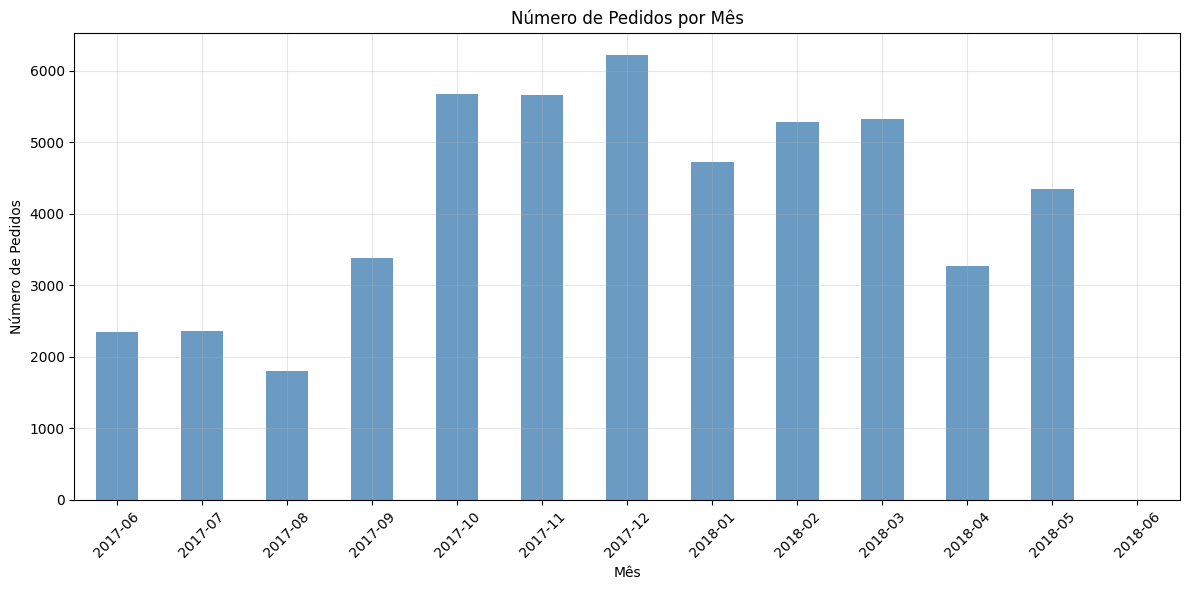

In [57]:
import matplotlib.pyplot as plt

# Criar gráfico de pedidos por mês
plt.figure(figsize=(12, 6))
pedidos_por_mes.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Número de Pedidos por Mês')
plt.xlabel('Mês')
plt.ylabel('Número de Pedidos')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [60]:
# Primeiro, criar a coluna order_month se ela não existir
orders_with_cohort['order_month'] = orders_with_cohort['Buy Ts'].dt.to_period('M')

# Depois, calcular a idade do coorte corretamente
orders_with_cohort['cohort_age'] = (orders_with_cohort['order_month'] - orders_with_cohort['acquisition_month']).apply(lambda x: x.n)

# Verificar se a coluna foi criada corretamente
print("Primeiros valores de cohort_age:")
print(orders_with_cohort['cohort_age'].head(10))

# Verificar a distribuição
print("\nDistribuição da idade do coorte:")
print(orders_with_cohort['cohort_age'].value_counts().sort_index())

Primeiros valores de cohort_age:
0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: cohort_age, dtype: int64

Distribuição da idade do coorte:
0     41588
1      2404
2      1519
3      1221
4       945
5       738
6       682
7       483
8       377
9       223
10      149
11       86
Name: cohort_age, dtype: int64


In [62]:

# # Criando uma tabela pivot com o número total de pedidos por coorte e por idade
orders_by_cohort = orders_with_cohort.pivot_table(
    index='acquisition_month',
    columns='cohort_age',
    values='Uid',
    aggfunc='count'
)

# Verificar se a tabela foi criada
print("Tabela de pedidos por coorte:")
print(orders_by_cohort.head())

# Ver as dimensões da tabela
print(f"\nDimensões: {orders_by_cohort.shape}")

# Ver alguns valores específicos
print(f"\nPrimeiros coortes e suas idades:")
print(orders_by_cohort.iloc[:3, :5])  # Primeiras 3 linhas e 5 colunas

Tabela de pedidos por coorte:
cohort_age             0      1      2      3      4      5      6      7   \
acquisition_month                                                            
2017-06            2354.0  177.0  174.0  226.0  292.0  218.0  276.0  174.0   
2017-07            2186.0  100.0  120.0  104.0   72.0   82.0   61.0   50.0   
2017-08            1533.0  108.0  100.0   81.0   85.0   62.0   49.0   78.0   
2017-09            2933.0  219.0  161.0  164.0   67.0  109.0  108.0   56.0   
2017-10            4964.0  314.0  162.0  122.0  129.0  103.0   86.0  125.0   

cohort_age            8      9     10    11  
acquisition_month                            
2017-06            212.0  153.0  96.0  86.0  
2017-07             58.0   24.0  53.0   NaN  
2017-08             46.0   46.0   NaN   NaN  
2017-09             61.0    NaN   NaN   NaN  
2017-10              NaN    NaN   NaN   NaN  

Dimensões: (13, 12)

Primeiros coortes e suas idades:
cohort_age              0      1      2      3

In [64]:
# # Obtendo o tamanho de cada coorte (número de clientes únicos que compraram pela 1ª vez em cada mês)
cohort_size = orders_with_cohort.groupby('acquisition_month')['Uid'].nunique()

# # Dividindo o número de pedidos pelo tamanho do coorte para obter a média
avg_orders_pivot = orders_by_cohort.divide(cohort_size, axis=0)

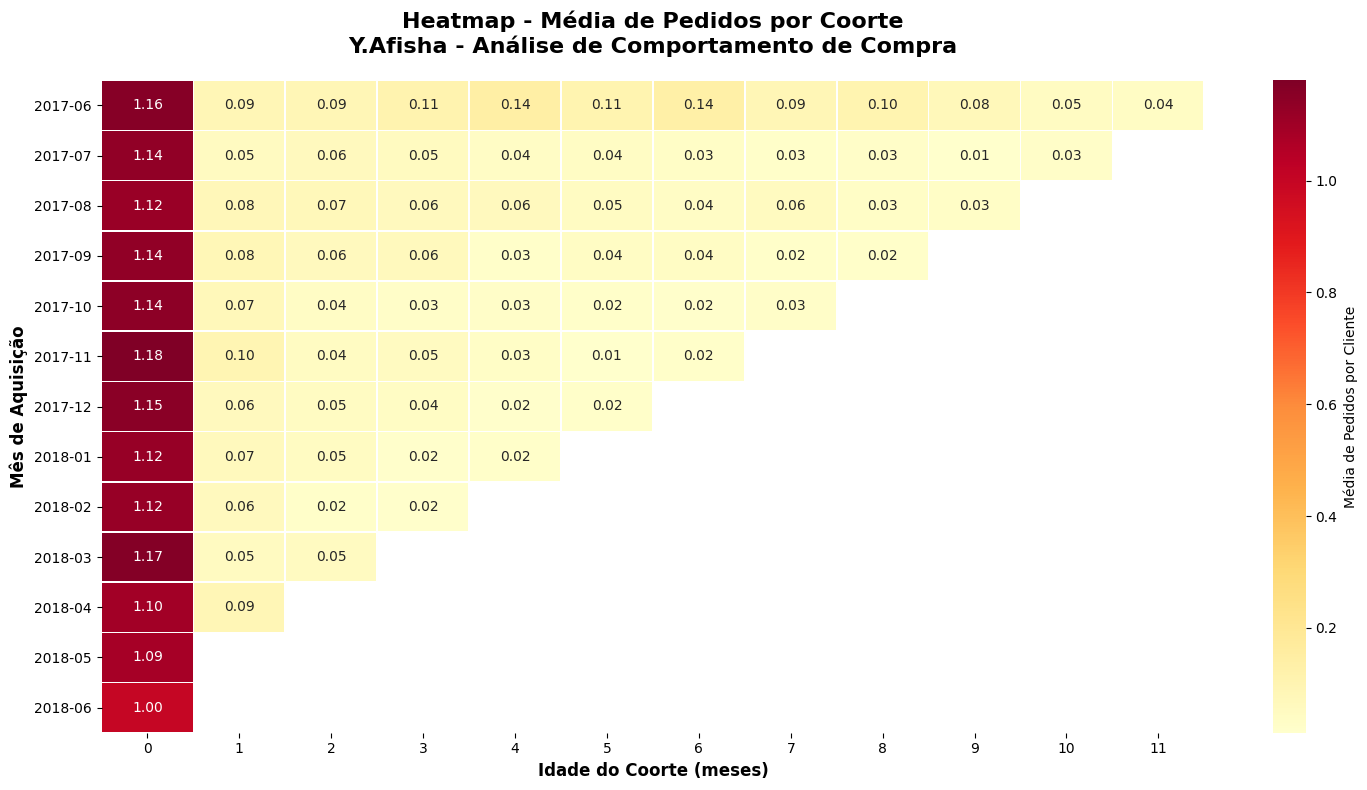

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o tamanho da figura
plt.figure(figsize=(15, 8))

# Criar o heatmap
sns.heatmap(avg_orders_pivot, 
            annot=True,           # Mostrar valores nas células
            fmt='.2f',            # Formato com 2 casas decimais
            cmap='YlOrRd',        # Paleta de cores (amarelo-laranja-vermelho)
            cbar_kws={'label': 'Média de Pedidos por Cliente'},
            linewidths=0.5)       # Linhas entre células

# Personalizar o gráfico
plt.title('Heatmap - Média de Pedidos por Coorte\nY.Afisha - Análise de Comportamento de Compra', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Idade do Coorte (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Mês de Aquisição', fontsize=12, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

In [69]:
# # --- Qual é o volume médio de uma compra? 

average_check = orders['Revenue'].mean()
print(f"O ticket médio geral é: ${average_check:.2f}")

# # Análise do Ticket Médio ao longo do tempo
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')
monthly_avg_check = orders.groupby('order_month')['Revenue'].mean()


O ticket médio geral é: $5.00


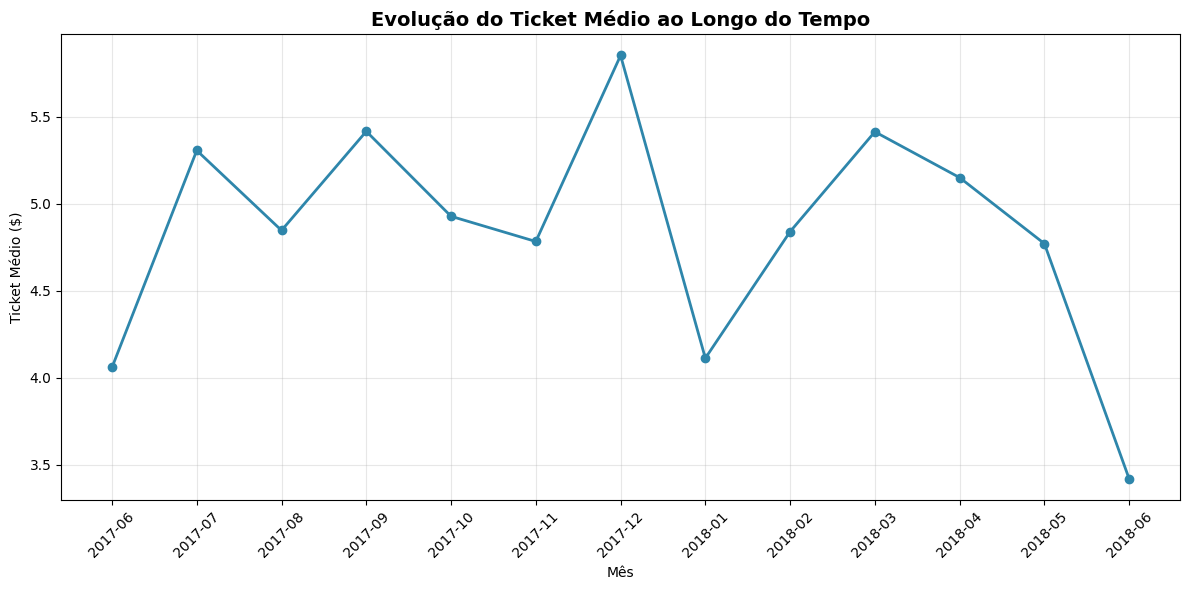

Ticket médio geral: $4.84
Maior ticket médio: $5.85
Menor ticket médio: $3.42


In [70]:
import matplotlib.pyplot as plt

# Criar gráfico de linha do ticket médio
plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_check.index.astype(str), monthly_avg_check.values, 
         marker='o', linewidth=2, markersize=6, color='#2E86AB')
plt.title('Evolução do Ticket Médio ao Longo do Tempo', fontsize=14, fontweight='bold')
plt.xlabel('Mês')
plt.ylabel('Ticket Médio ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar algumas estatísticas
print(f"Ticket médio geral: ${monthly_avg_check.mean():.2f}")
print(f"Maior ticket médio: ${monthly_avg_check.max():.2f}")
print(f"Menor ticket médio: ${monthly_avg_check.min():.2f}")

In [71]:
# --- Quanto dinheiro eles trazem para a empresa (LTV)?

# Definindo o mês de aquisição (primeira compra) como o coorte
orders['acquisition_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').dt.to_period('M')

# Calculando a idade do coorte para cada pedido
orders['cohort_lifetime'] = ((orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n))

# Calculando a receita por coorte e por idade
cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['Revenue'].sum().reset_index()

# Obtendo o tamanho de cada coorte (número de clientes únicos)
cohort_sizes = orders.groupby('acquisition_month')['Uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']

# Unindo os dados de receita e tamanho do coorte
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')

# LTV
cohorts_data['ltv'] = cohorts_data['Revenue'] / cohorts_data['n_buyers']

# Tabela pivot para o LTV
ltv_pivot = cohorts_data.pivot_table(index='acquisition_month',
                                      columns='cohort_lifetime',
                                      values='ltv',
                                      aggfunc='sum').cumsum(axis=1)

print(" Análise de LTV criada com sucesso!")
print(f"Dimensões da tabela LTV: {ltv_pivot.shape}")

 Análise de LTV criada com sucesso!
Dimensões da tabela LTV: (13, 12)


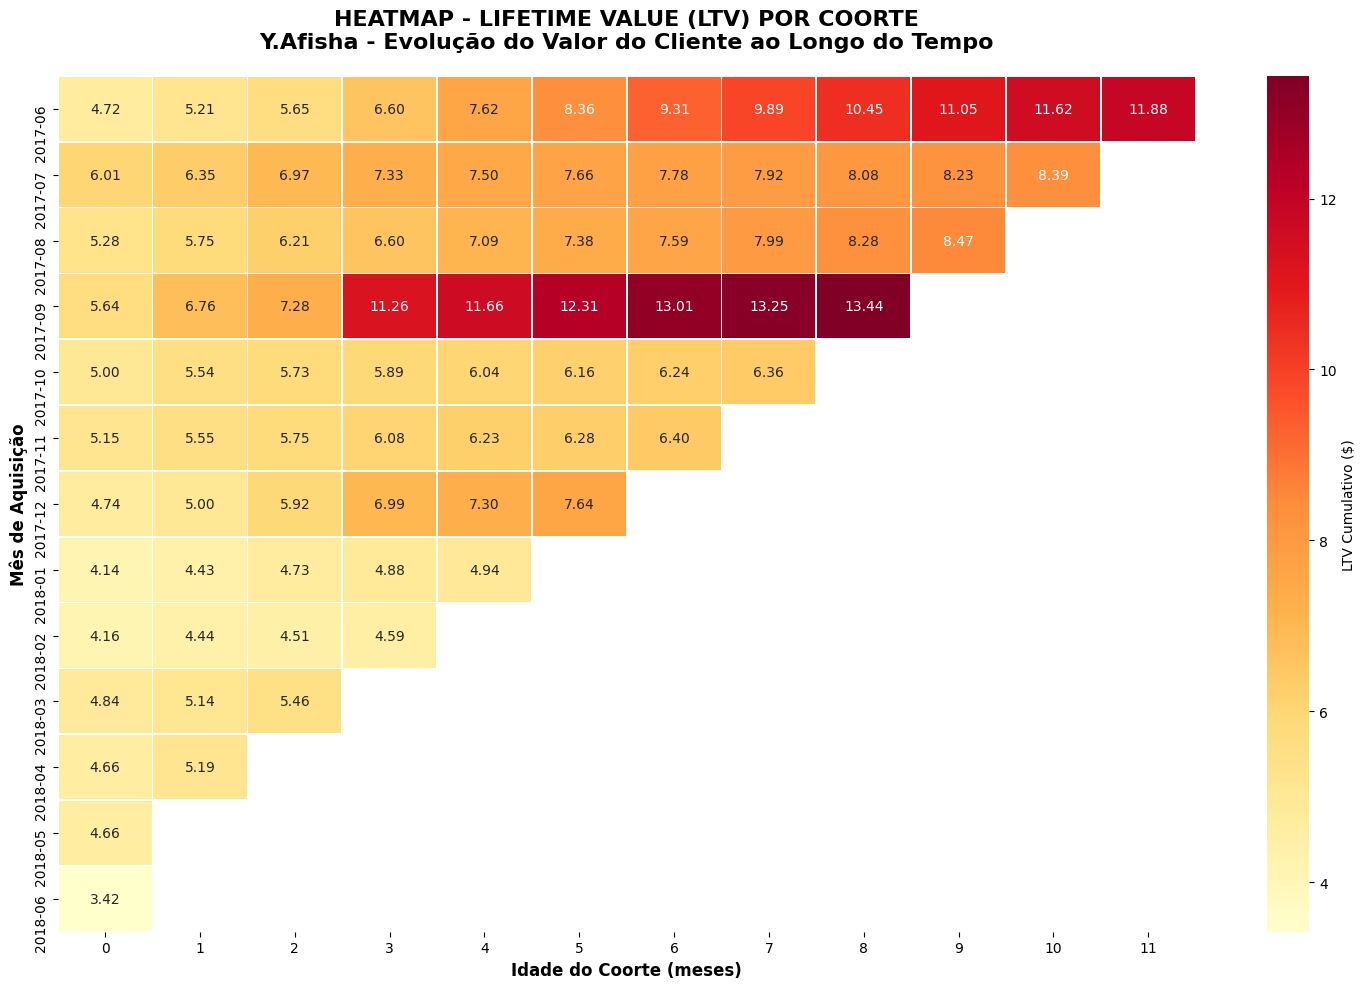

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o tamanho da figura
plt.figure(figsize=(15, 10))

# Criar o heatmap do LTV
sns.heatmap(ltv_pivot,
            annot=True,           # Mostrar valores nas células
            fmt='.2f',            # Formato com 2 casas decimais
            cmap='YlOrRd',        # Paleta de cores (amarelo-laranja-vermelho)
            cbar_kws={'label': 'LTV Cumulativo ($)'},
            linewidths=0.5,       # Linhas entre células
            square=False)         # Células não quadradas

# Personalizar o gráfico
plt.title('HEATMAP - LIFETIME VALUE (LTV) POR COORTE\nY.Afisha - Evolução do Valor do Cliente ao Longo do Tempo',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Idade do Coorte (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Mês de Aquisição', fontsize=12, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

In [74]:

# Verificar se temos os dados de custos
print("✅ Verificando dados de custos:")
print(f"Dados de costs: {len(costs)} registros")
print(f"Colunas: {costs.columns.tolist()}")
print(f"Primeiras linhas:")
print(costs.head())

✅ Verificando dados de custos:
Dados de costs: 2542 registros
Colunas: ['source_id', 'dt', 'costs']
Primeiras linhas:
   source_id         dt  costs
0          1 2017-06-01  75.20
1          1 2017-06-02  62.25
2          1 2017-06-03  36.53
3          1 2017-06-04  55.00
4          1 2017-06-05  57.08


In [75]:
# Adicionando uma coluna de mês para agrupar os custos
costs['month'] = costs['dt'].dt.to_period('M')

# Criar uma tabela dinâmica (pivot) para organizar os dados para o gráfico
costs_pivot = costs.pivot_table(
    index='month',
    columns='source_id',
    values='costs',
    aggfunc='sum'
).fillna(0)

print("✅ costs_pivot criado com sucesso!")
print(f"Dimensões: {costs_pivot.shape}")
print("\nPrimeiras linhas:")
print(costs_pivot.head())

✅ costs_pivot criado com sucesso!
Dimensões: (12, 7)

Primeiras linhas:
source_id       1        2         3        4        5       9       10
month                                                                  
2017-06    1125.61  2427.38   7731.65  3514.80  2616.12  285.22  314.22
2017-07    1072.88  2333.11   7674.37  3529.73  2998.14  302.54  329.82
2017-08     951.81  1811.05   6143.54  3217.36  2185.28  248.93  232.57
2017-09    1502.01  2985.66   9963.55  5192.26  3849.14  415.62  460.67
2017-10    2315.75  4845.00  15737.24  6420.84  5767.40  609.41  627.24


<Figure size 1500x800 with 0 Axes>

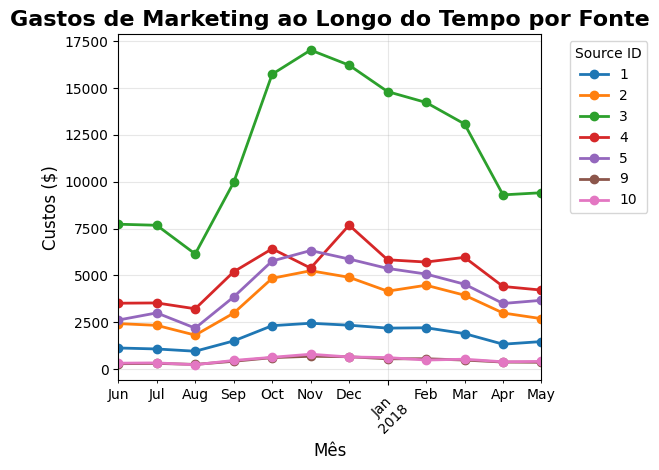

In [76]:
import matplotlib.pyplot as plt

# Plotando o gráfico de linhas a partir da tabela dinâmica
plt.figure(figsize=(15, 8))
costs_pivot.plot(kind='line', marker='o', linewidth=2, markersize=6)

plt.title('Gastos de Marketing ao Longo do Tempo por Fonte', fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Custos ($)', fontsize=12)
plt.legend(title='Source ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
# --- Quanto custou a aquisição de clientes (CAC)?

# Adicionando uma coluna de mês aos custos
costs['month'] = costs['dt'].dt.to_period('M')

# Encontrando a primeira visita de cada usuário para obter a fonte de aquisição
first_visits = visits.sort_values('Start Ts').drop_duplicates('Uid')
first_visits = first_visits[['Uid', 'Source Id']]

# Encontrando o mês da primeira compra de cada cliente
first_orders = orders.sort_values('Buy Ts').drop_duplicates('Uid')
first_orders['acquisition_month'] = first_orders['Buy Ts'].dt.to_period('M')
first_orders = first_orders[['Uid', 'acquisition_month']]

# Unindo as informações para saber a fonte e o mês de aquisição de cada cliente
buyers = pd.merge(first_orders, first_visits, on='Uid')

# Calculando o número de clientes adquiridos por mês e por fonte
buyers_by_month_source = buyers.groupby(['acquisition_month', 'Source Id'])['Uid'].nunique().reset_index()
buyers_by_month_source.columns = ['month', 'source_id', 'n_buyers']

# Formatando os custos mensais por fonte
costs_by_month_source = costs.groupby(['month', 'source_id'])['costs'].sum().reset_index()

# Unindo custos e número de compradores por mês e fonte
cac_monthly_data = pd.merge(costs_by_month_source, buyers_by_month_source, on=['month', 'source_id'])

# CAC mensal para cada fonte
cac_monthly_data = cac_monthly_data[cac_monthly_data['n_buyers'] > 0]
cac_monthly_data['cac'] = cac_monthly_data['costs'] / cac_monthly_data['n_buyers']

# Tabela dinâmica (pivot) para a plotagem
cac_pivot = cac_monthly_data.pivot_table(
    index='month',
    columns='source_id',
    values='cac'
)

print("✅ CAC calculado com sucesso!")
print(f"Dimensões: {cac_pivot.shape}")

✅ CAC calculado com sucesso!
Dimensões: (12, 7)


<Figure size 1500x800 with 0 Axes>

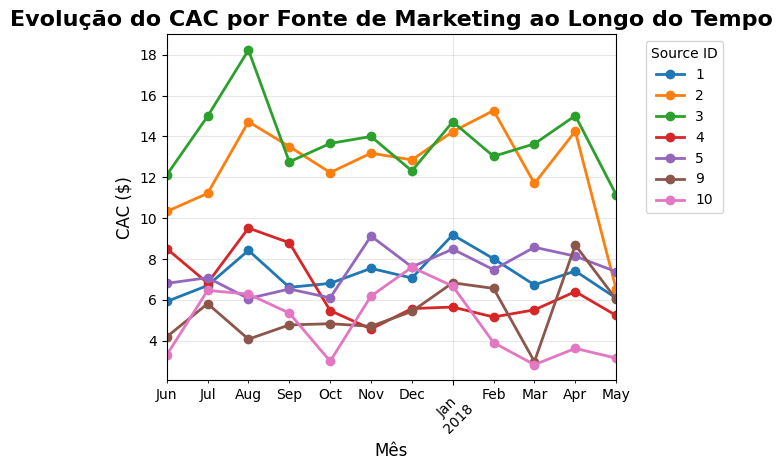

ESTATÍSTICAS DO CAC:
CAC médio geral: $8.24
CAC mais baixo: $2.83
CAC mais alto: $18.23

CAC médio por fonte:
  Fonte 1: $7.21
  Fonte 2: $12.50
  Fonte 3: $13.80
  Fonte 4: $6.44
  Fonte 5: $7.45
  Fonte 9: $5.41
  Fonte 10: $4.87


In [80]:
import matplotlib.pyplot as plt

# Gráfico de linhas do CAC
plt.figure(figsize=(15, 8))
cac_pivot.plot(kind='line', marker='o', linewidth=2, markersize=6)

plt.title('Evolução do CAC por Fonte de Marketing ao Longo do Tempo', 
          fontsize=16, fontweight='bold')
plt.xlabel('Mês', fontsize=12)
plt.ylabel('CAC ($)', fontsize=12)
plt.legend(title='Source ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Estatísticas do CAC
print("ESTATÍSTICAS DO CAC:")
print("=" * 50)
print(f"CAC médio geral: ${cac_pivot.mean().mean():.2f}")
print(f"CAC mais baixo: ${cac_pivot.min().min():.2f}")
print(f"CAC mais alto: ${cac_pivot.max().max():.2f}")
print("\nCAC médio por fonte:")
for source in cac_pivot.columns:
    avg_cac = cac_pivot[source].mean()
    print(f"  Fonte {source}: ${avg_cac:.2f}")

In [85]:
# --- Os investimentos valeram a pena? 

# LTV acumulado por coorte
orders['acquisition_month'] = orders.groupby('Uid')['Buy Ts'].transform('min').dt.to_period('M')
orders['order_month'] = orders['Buy Ts'].dt.to_period('M')
orders['cohort_lifetime'] = (orders['order_month'] - orders['acquisition_month']).apply(lambda x: x.n)
cohorts_revenue = orders.groupby(['acquisition_month', 'cohort_lifetime'])['Revenue'].sum().reset_index()
cohort_sizes = orders.groupby('acquisition_month')['Uid'].nunique().reset_index()
cohort_sizes.columns = ['acquisition_month', 'n_buyers']
cohorts_data = pd.merge(cohorts_revenue, cohort_sizes, on='acquisition_month')
cohorts_data['ltv'] = cohorts_data['Revenue'] / cohorts_data['n_buyers']
ltv_pivot = cohorts_data.pivot_table(index='acquisition_month', columns='cohort_lifetime', values='ltv').cumsum(axis=1)


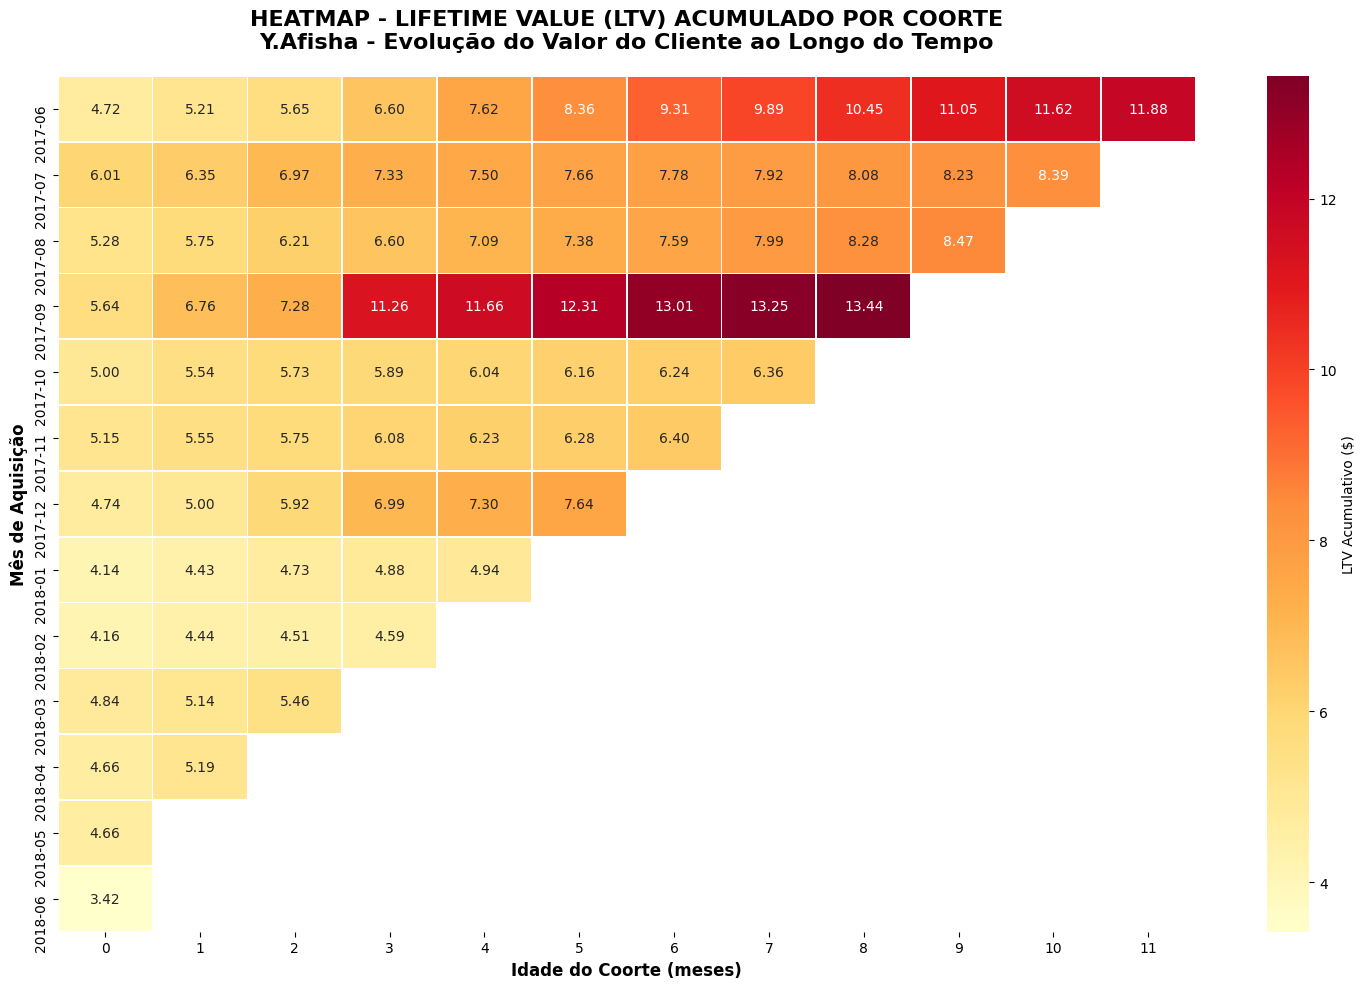

📊 ESTATÍSTICAS DO LTV:
• LTV médio no 1º mês: $4.80
• LTV médio no 6º mês: $7.97
• Maior LTV acumulado: $13.44


In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o tamanho da figura
plt.figure(figsize=(15, 10))

# Criar o heatmap do LTV acumulado
sns.heatmap(ltv_pivot,
            annot=True,           # Mostrar valores nas células
            fmt='.2f',            # Formato com 2 casas decimais
            cmap='YlOrRd',        # Paleta de cores (amarelo-laranja-vermelho)
            cbar_kws={'label': 'LTV Acumulativo ($)'},
            linewidths=0.5,       # Linhas entre células
            square=False)         # Células não quadradas

# Personalizar o gráfico
plt.title('HEATMAP - LIFETIME VALUE (LTV) ACUMULADO POR COORTE\nY.Afisha - Evolução do Valor do Cliente ao Longo do Tempo',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Idade do Coorte (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Mês de Aquisição', fontsize=12, fontweight='bold')

# Ajustar layout
plt.tight_layout()
plt.show()

# Estatísticas do LTV
print(" ESTATÍSTICAS DO LTV:")
print("=" * 50)
print(f"• LTV médio no 1º mês: ${ltv_pivot.iloc[:, 0].mean():.2f}")
print(f"• LTV médio no 6º mês: ${ltv_pivot.iloc[:, 5].mean():.2f}")
print(f"• Maior LTV acumulado: ${ltv_pivot.max().max():.2f}")

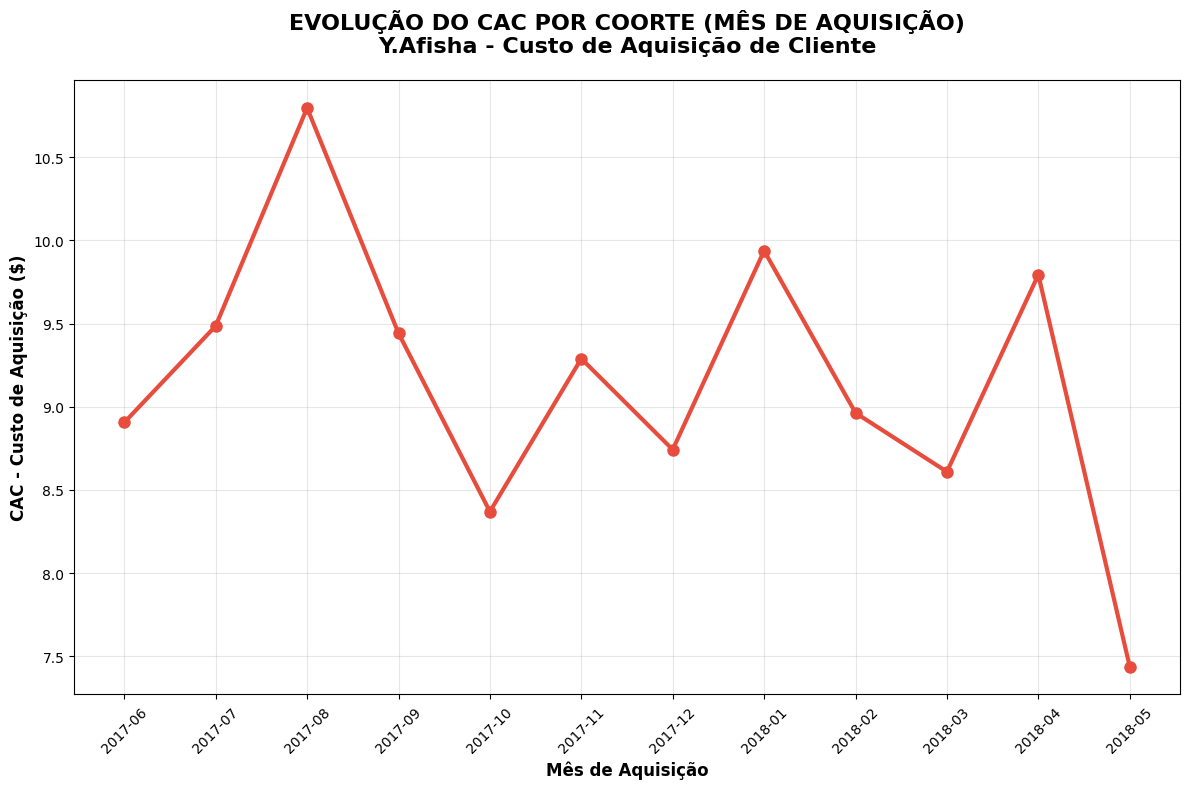

📊 ESTATÍSTICAS DO CAC POR COORTE:
• CAC médio: $9.15
• CAC mais baixo: $7.44
• CAC mais alto: $10.80
• Variação: 36.7%


In [88]:

# # CAC por coorte (mês de aquisição)
costs['month'] = costs['dt'].dt.to_period('M')
first_orders = orders.sort_values('Buy Ts').drop_duplicates('Uid')
first_orders['acquisition_month'] = first_orders['Buy Ts'].dt.to_period('M')
n_buyers_by_cohort = first_orders.groupby('acquisition_month')['Uid'].nunique().reset_index()
n_buyers_by_cohort.columns = ['month', 'n_buyers']
costs_by_cohort = costs.groupby('month')['costs'].sum().reset_index()
cac_by_cohort = pd.merge(costs_by_cohort, n_buyers_by_cohort, on='month')
cac_by_cohort['cac'] = cac_by_cohort['costs'] / cac_by_cohort['n_buyers']
cac_by_cohort = cac_by_cohort[['month', 'cac']]
cac_by_cohort.columns = ['acquisition_month', 'cac']

import matplotlib.pyplot as plt
import seaborn as sns

# Visualização do CAC por coorte
plt.figure(figsize=(12, 8))

# Gráfico de linha do CAC por mês de aquisição
plt.plot(cac_by_cohort['acquisition_month'].astype(str), 
         cac_by_cohort['cac'], 
         marker='o', linewidth=3, markersize=8, color='#E74C3C')

plt.title('EVOLUÇÃO DO CAC POR COORTE (MÊS DE AQUISIÇÃO)\nY.Afisha - Custo de Aquisição de Cliente', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Mês de Aquisição', fontsize=12, fontweight='bold')
plt.ylabel('CAC - Custo de Aquisição ($)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estatísticas do CAC
print("📊 ESTATÍSTICAS DO CAC POR COORTE:")
print("=" * 50)
print(f"• CAC médio: ${cac_by_cohort['cac'].mean():.2f}")
print(f"• CAC mais baixo: ${cac_by_cohort['cac'].min():.2f}")
print(f"• CAC mais alto: ${cac_by_cohort['cac'].max():.2f}")
print(f"• Variação: {((cac_by_cohort['cac'].max() - cac_by_cohort['cac'].min()) / cac_by_cohort['cac'].mean() * 100):.1f}%")



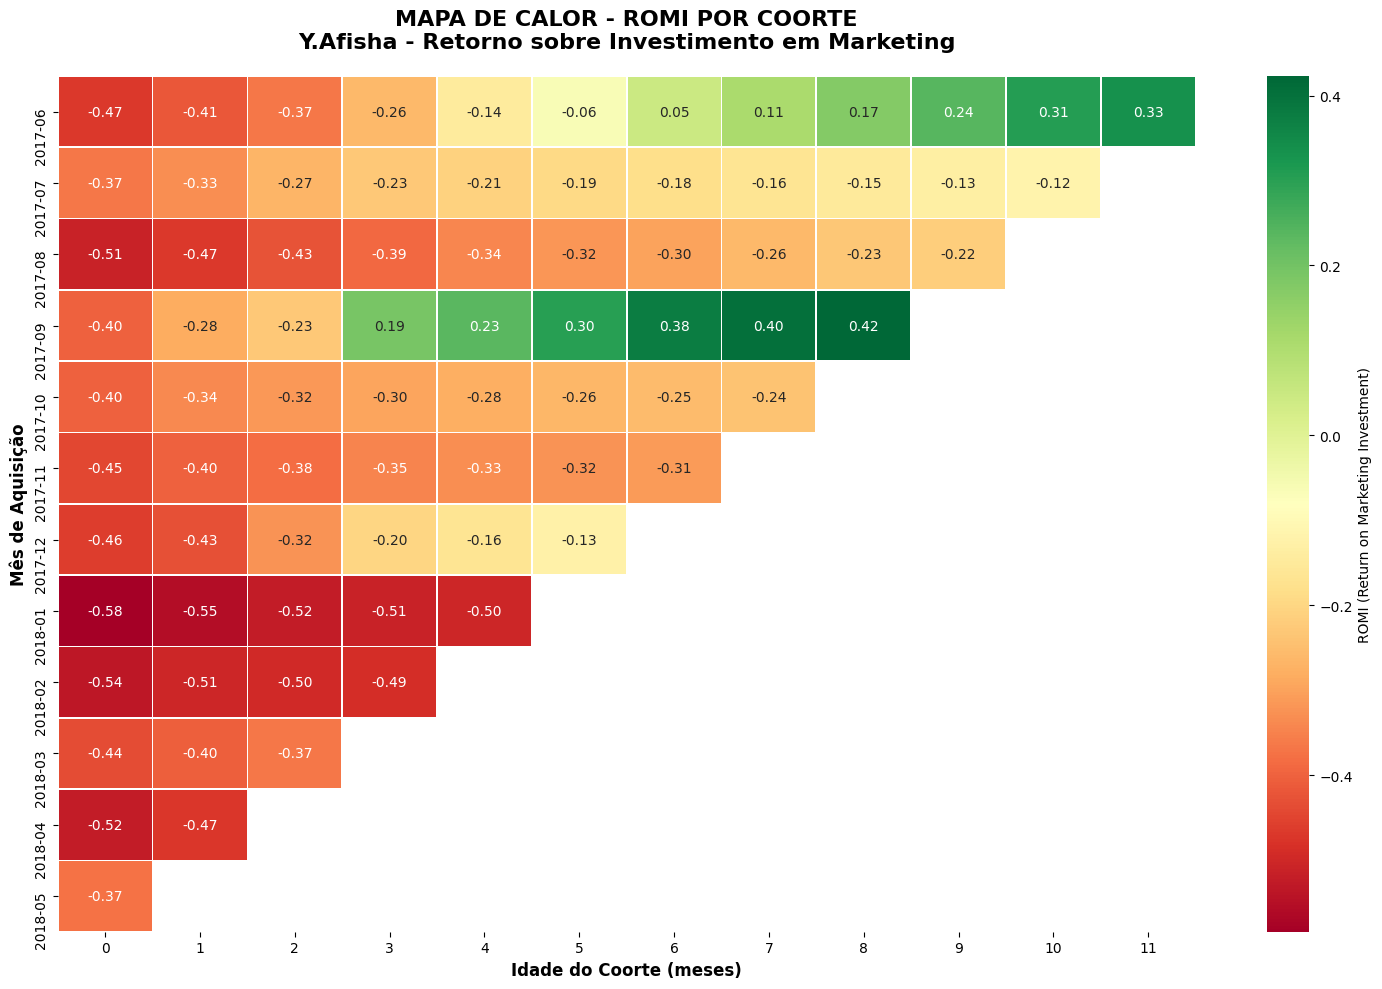

In [94]:
# Combinar LTV e CAC
report = pd.merge(ltv_pivot.reset_index(), cac_by_cohort, on='acquisition_month')
report = report.set_index('acquisition_month')

# Separar CAC e LTV
cac_values = report['cac']
ltv_values = report.drop(columns=['cac'])

# Calcular ROMI: (LTV - CAC) / CAC
romi_pivot = ltv_values.subtract(cac_values, axis=0).divide(cac_values, axis=0)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
sns.heatmap(romi_pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',  # Verde = bom ROMI, Vermelho = ROMI ruim
            cbar_kws={'label': 'ROMI (Return on Marketing Investment)'},
            linewidths=0.5)

plt.title('MAPA DE CALOR - ROMI POR COORTE\nY.Afisha - Retorno sobre Investimento em Marketing',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Idade do Coorte (meses)', fontsize=12, fontweight='bold')
plt.ylabel('Mês de Aquisição', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [68]:

# Contar quantas sessões cada usuário fez
sessions_per_user = visits.groupby('Uid').size()
print("Distribuição de sessões por usuário:")
print(sessions_per_user.describe())

Distribuição de sessões por usuário:
count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64


In [19]:
#75% dos usuários fazem apenas 1 sessão (1º e 3º quartis = 1)
#Média de 1,57 sessões por usuário
#Máximo de 893 sessões (usuário muito engajado!)
#Isso sugere que a maioria dos usuários são visitantes únicos

In [20]:
# Identificar usuários que compraram
buyers_list = orders['Uid'].unique()

# Separar sessões por tipo de usuário
buyers_sessions = visits[visits['Uid'].isin(buyers_list)].groupby('Uid').size()
non_buyers_sessions = visits[~visits['Uid'].isin(buyers_list)].groupby('Uid').size()

print(" COMPARAÇÃO: COMPRADORES vs NÃO-COMPRADORES")
print("\nCompradores:")
print(buyers_sessions.describe())
print("\nNão-compradores:")
print(non_buyers_sessions.describe())

 COMPARAÇÃO: COMPRADORES vs NÃO-COMPRADORES

Compradores:
count    36523.000000
mean         2.666648
std          8.468150
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        615.000000
dtype: float64

Não-compradores:
count    191646.000000
mean          1.367135
std           3.430995
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64


In [21]:
#Compradores: média de 2,67 sessões vs 1,37 sessões dos não-compradores
#75% dos compradores fazem até 3 sessões vs apenas 1 sessão dos não-compradores
#Os compradores fazem quase 2x mais sessões em média!

In [22]:
# Criar segmentos por número de sessões
def categorize_sessions(sessions):
    if sessions == 1:
        return '1 sessão'
    elif sessions <= 3:
        return '2-3 sessões'
    elif sessions <= 10:
        return '4-10 sessões'
    else:
        return '11+ sessões'

# Aplicar categorização
sessions_per_user_df = sessions_per_user.reset_index()
sessions_per_user_df.columns = ['Uid', 'sessions_count']
sessions_per_user_df['session_category'] = sessions_per_user_df['sessions_count'].apply(categorize_sessions)

print("Distribuição por categoria:")
print(sessions_per_user_df['session_category'].value_counts())

Distribuição por categoria:
1 sessão        176041
2-3 sessões      41110
4-10 sessões      9798
11+ sessões       1220
Name: session_category, dtype: int64


In [23]:
#1 sessão: 176.041 usuários (77,2% do total)
#2-3 sessões: 41.110 usuários (18,0% do total)
#4-10 sessões: 9.798 usuários (4,3% do total)
#11+ sessões: 1.220 usuários (0,5% do total)
#Isso mostra uma distribuição típica em funil, onde a maioria dos usuários visita apenas uma vez.

In [24]:
# Carregar dados de custos de marketing
costs = pd.read_csv('/datasets/costs_us.csv')

print(" Informações sobre dados de custos:")
print(costs.info())
print("\n Primeiras linhas:")
print(costs.head())
print("\n Estatísticas descritivas:")
print(costs.describe())


 Informações sobre dados de custos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB
None

 Primeiras linhas:
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06-03  36.53
3          1  2017-06-04  55.00
4          1  2017-06-05  57.08

 Estatísticas descritivas:
         source_id        costs
count  2542.000000  2542.000000
mean      4.857199   129.477427
std       3.181581   156.296628
min       1.000000     0.540000
25%       2.000000    21.945000
50%       4.000000    77.295000
75%       9.000000   170.065000
max      10.000000  1788.280000


In [25]:
# Calcular gastos totais por fonte de marketing
gastos_por_fonte = costs.groupby('source_id')['costs'].sum().sort_values(ascending=False)

print("💰 GASTOS TOTAIS POR FONTE DE MARKETING:")
print(gastos_por_fonte)
print(f"\nTotal geral investido: ${gastos_por_fonte.sum():,.2f}")

💰 GASTOS TOTAIS POR FONTE DE MARKETING:
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64

Total geral investido: $329,131.62


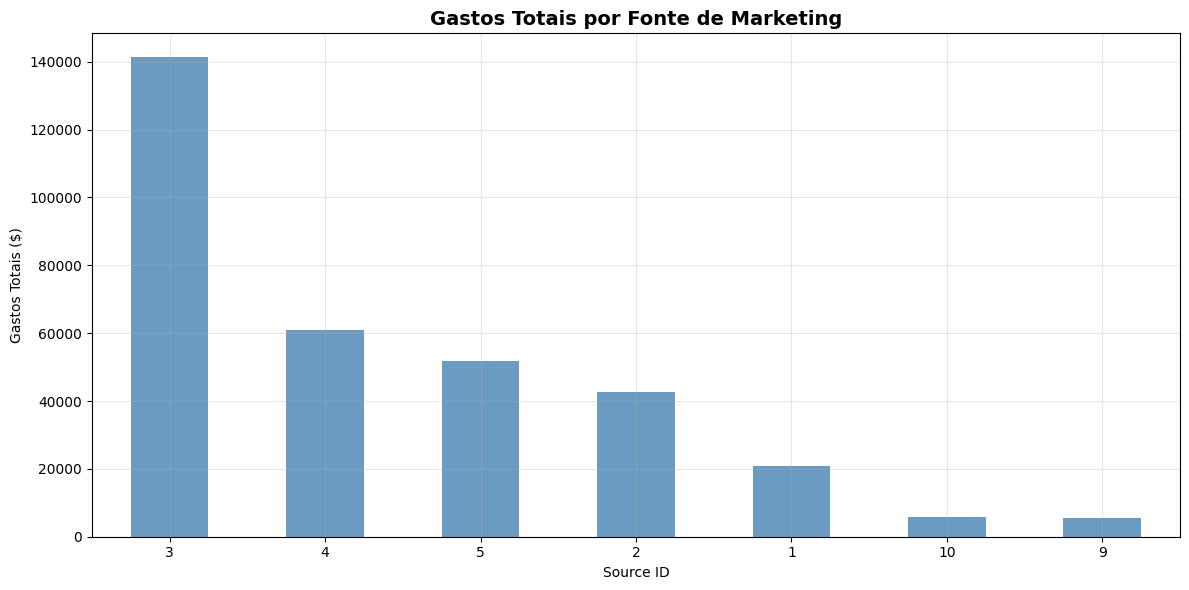

In [26]:
import matplotlib.pyplot as plt

# Criar gráfico dos gastos por fonte
plt.figure(figsize=(12, 6))
gastos_por_fonte.plot(kind='bar', color='steelblue', alpha=0.8)
plt.title('Gastos Totais por Fonte de Marketing', fontsize=14, fontweight='bold')
plt.xlabel('Source ID')
plt.ylabel('Gastos Totais ($)')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# Gastos totais
total_costs = costs['costs'].sum()
print("Gasto total em marketing:", total_costs)

# Gastos por origem
costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index()
print(costs_by_source)


Gasto total em marketing: 329131.62
   source_id      costs
0          1   20833.27
1          2   42806.04
2          3  141321.63
3          4   61073.60
4          5   51757.10
5          9    5517.49
6         10    5822.49


In [28]:
#Gasto total: $329.131,62
#Fonte 3 é a que mais consome orçamento: $141.321,63 (43% do total!)
#Fonte 2 em segundo lugar: $42.806,04 (13% do total)
#Fontes 9 e 10 têm gastos muito baixos: ~$5.500 cada

In [29]:
# Corrigindo o nome da coluna - é 'Uid', não 'User Id'
usuarios_por_fonte = visits.groupby('Source Id')['Uid'].nunique().reset_index()
usuarios_por_fonte.columns = ['source_id', 'total_usuarios']
print(" Usuários únicos por fonte:")
print(usuarios_por_fonte)

👥 Usuários únicos por fonte:
   source_id  total_usuarios
0          1           18999
1          2           26245
2          3           74756
3          4           83525
4          5           56974
5          6               6
6          7              34
7          9            9264
8         10            8067


In [30]:
#Fontes com MUITO volume:

#Fonte 4: 83.525 usuários (maior volume!) - mas não tem custos registrados
#Fonte 3: 74.756 usuários + $141.321 gastos
#Fonte 2: 26.245 usuários + $42.806 gastos
#Fontes com POUCO volume:

#Fontes 6 e 7: apenas 6 e 34 usuários (sem custos registrados)
#Fontes 9 e 10: ~8-9k usuários cada + ~$5.500 gastos

In [31]:
# Calcular conversões (usuários que compraram) por fonte
conversoes_por_fonte = visits[visits['Uid'].isin(orders['Uid'].unique())].groupby('Source Id')['Uid'].nunique().reset_index()
conversoes_por_fonte.columns = ['source_id', 'conversoes']
print("🛒 Conversões por fonte:")
print(conversoes_por_fonte)

🛒 Conversões por fonte:
   source_id  conversoes
0          1        7138
1          2        7305
2          3       13846
3          4       14253
4          5       10156
5          7           1
6          9        2793
7         10        1773


In [32]:
# Criar tabela completa para análise de CAC
import pandas as pd

# Dados de gastos
gastos_df = costs.groupby('source_id')['costs'].sum().reset_index()

# Dados de usuários (já temos)
usuarios_df = usuarios_por_fonte.copy()

# Dados de conversões (já temos)
conversoes_df = conversoes_por_fonte.copy()

# Combinar todos os dados
cac_analysis = gastos_df.merge(usuarios_df, on='source_id', how='outer')
cac_analysis = cac_analysis.merge(conversoes_df, on='source_id', how='outer')

# Preencher valores NaN com 0
cac_analysis = cac_analysis.fillna(0)

# Calcular CAC (Custo ÷ Conversões)
cac_analysis['CAC'] = cac_analysis['costs'] / cac_analysis['conversoes']
cac_analysis['CAC'] = cac_analysis['CAC'].replace([float('inf')], 0)  # Substituir infinito por 0

# Calcular taxa de conversão por fonte
cac_analysis['taxa_conversao'] = (cac_analysis['conversoes'] / cac_analysis['total_usuarios']) * 100

print("📊 ANÁLISE COMPLETA DE CAC POR FONTE:")
print(cac_analysis.round(2))

📊 ANÁLISE COMPLETA DE CAC POR FONTE:
   source_id      costs  total_usuarios  conversoes    CAC  taxa_conversao
0          1   20833.27           18999      7138.0   2.92           37.57
1          2   42806.04           26245      7305.0   5.86           27.83
2          3  141321.63           74756     13846.0  10.21           18.52
3          4   61073.60           83525     14253.0   4.28           17.06
4          5   51757.10           56974     10156.0   5.10           17.83
5          9    5517.49            9264      2793.0   1.98           30.15
6         10    5822.49            8067      1773.0   3.28           21.98
7          6       0.00               6         0.0    NaN            0.00
8          7       0.00              34         1.0   0.00            2.94


<s>
<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- há um erro de lógica aqui pois para calcular CAC precisa saber a fonte de aquisição

</div>

In [33]:
#Fonte 9 tem o menor CAC (R$ 1,98) e uma taxa de conversão alta (30,15%)
#Fonte 3 tem o maior CAC (R$ 10,21) mas também o maior volume de conversões
#Fontes 6 e 7 têm dados limitados ou zerados

#Equilíbrio CAC vs. volume:
#Fonte 9 é ótima em eficiência, mas não escala tanto.
#Fonte 3 escala muito, mas custa caro.
#Fonte 1 parece ser um bom meio-termo: CAC baixo e volume razoável.
#CAC alto + muitas conversões:
#Pode valer a pena se o LTV dos clientes dessa fonte for alto.
#Exemplo: Fonte 3 pode ser cara, mas se os clientes compram repetidamente, o investimento compensa.
#CAC baixo + poucas conversões:
#Bom para eficiência, mas não sustenta crescimento sozinho.
#Exemplo: Fonte 9 é excelente, mas não pode ser o único canal.
#Fontes 6 e 7: Dados limitados sugerem que não são relevantes para a estratégia atual.
#Talvez não tenham campanhas ativas ou sejam testes.
 

In [34]:
# Estatísticas básicas da receita
orders['Revenue'].describe()

count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: Revenue, dtype: float64

In [35]:
#Receita média: $4,99 por pedido
#Mediana: $2,50 (metade dos pedidos vale menos que isso)
#75% dos pedidos: até $4,89
#Pedido máximo: $2.633,28 (outlier interessante!)

In [36]:
# Conectar orders com visits através do Uid
orders_with_source = orders.merge(visits[['Uid', 'Source Id']], on='Uid', how='left')

In [37]:
# Receita total por fonte
revenue_by_source = orders_with_source.groupby('Source Id')['Revenue'].sum().reset_index()
revenue_by_source.columns = ['source_id','total_revenue']
print("💰 Receita total por fonte:")
print(revenue_by_source)

# Ticket médio por fonte
avg_ticket_by_source = orders_with_source.groupby('Source Id')['Revenue'].mean().reset_index()
avg_ticket_by_source.columns = ['source_id','avg_ticket']
print("🎟️ Ticket médio por fonte:")
print(avg_ticket_by_source)


💰 Receita total por fonte:
   source_id  total_revenue
0          1   2.298200e+06
1          2   2.638189e+06
2          3   2.966880e+05
3          4   4.966902e+05
4          5   1.181477e+06
5          7   1.220000e+00
6          9   3.634225e+04
7         10   1.461923e+04
🎟️ Ticket médio por fonte:
   source_id  avg_ticket
0          1    9.242265
1          2   11.071013
2          3    6.344095
3          4    7.923842
4          5    7.781887
5          7    1.220000
6          9    3.806667
7         10    3.630303


In [38]:
#Fontes 1 e 2 são as grandes geradoras de receita, com ticket médio alto.
#Fonte 3 tem muitas conversões (como vimos antes), mas gera pouco em receita → clientes gastam pouco.
#Fonte 9 foi super eficiente em CAC, mas aqui vemos que o ticket médio é baixo e a receita total também.
#Fonte 7 praticamente não contribui, confirmando que não é relevante.

In [39]:
# ROI = (Receita - Custo) / Custo * 100
roi_analysis = revenue_by_source.merge(costs_by_source, on='source_id')
roi_analysis['roi'] = (roi_analysis['total_revenue'] - roi_analysis['costs']) / roi_analysis['costs'] * 100

In [40]:
print("🚀 ANÁLISE DE ROI POR FONTE:")
print(roi_analysis.round(2))

🚀 ANÁLISE DE ROI POR FONTE:
   source_id  total_revenue      costs       roi
0          1     2298200.17   20833.27  10931.39
1          2     2638189.21   42806.04   6063.12
2          3      296687.96  141321.63    109.94
3          4      496690.17   61073.60    713.26
4          5     1181477.14   51757.10   2182.73
5          9       36342.25    5517.49    558.67
6         10       14619.23    5822.49    151.08


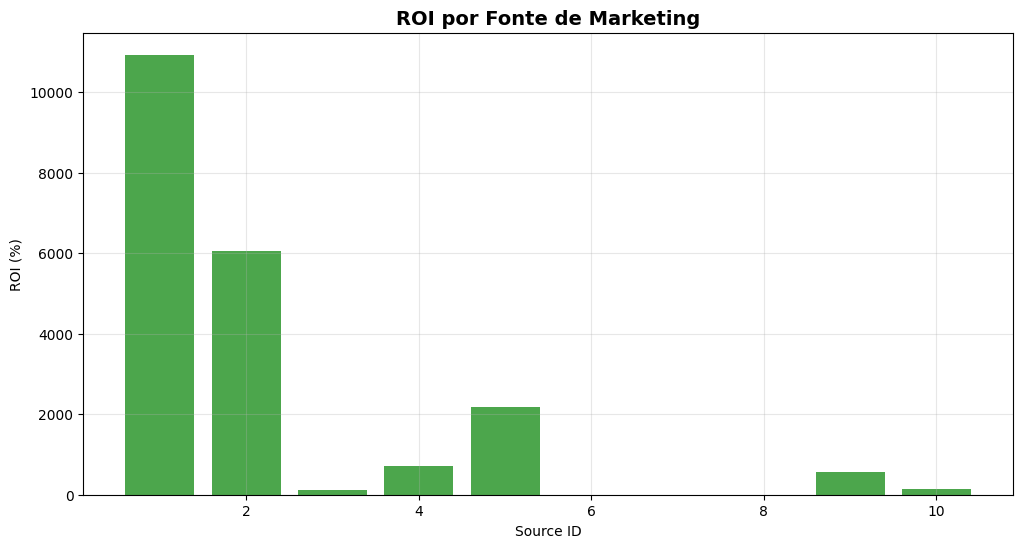

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(roi_analysis['source_id'], roi_analysis['roi'], color='green', alpha=0.7)
plt.title('ROI por Fonte de Marketing', fontsize=14, fontweight='bold')
plt.xlabel('Source ID')
plt.ylabel('ROI (%)')
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
#As fontes mais rentáveis:
#Fonte 1: ROI de 10.931% - Incrível retorno!
#Fonte 2: ROI de 6.063% - Também muito forte
#Fonte 5: ROI de 2.183% - Boa performance

#As fontes menos rentáveis:
#Fonte 3: ROI de apenas 110% - A mais baixa
#Fonte 10: ROI de 151%


#Fonte 9: tinha o menor CAC (R$ 1,98), mas ROI de 559%. Isso acontece porque, apesar de ser barata para adquirir clientes, o ticket médio é baixo e a receita total também. Ou seja, é eficiente, mas não escala.
#Fonte 3: trouxe o maior volume de visitantes, mas ROI de apenas 110%. Isso mostra que quantidade não significa qualidade — muitos usuários vieram, mas gastaram pouco.
#Fonte 1 vs. Fonte 2:
#Fonte 1 → ROI quase 2x maior (10.931%), mas receita total menor que a Fonte 2.
#Fonte 2 → ROI menor (6.063%), mas receita total mais alta (≈ 2,63 milhões).
#Estratégia: Fonte 1 é mais eficiente, Fonte 2 é mais escalável.

In [43]:
#Se o objetivo é maximizar ROI → investir mais em Fonte 1 e manter Fonte 5 como apoio.
#Se o objetivo é maximizar receita absoluta → priorizar Fonte 2, mesmo com ROI menor, porque ela gera o maior volume de vendas.
#Equilíbrio ideal → combinar Fonte 1 (eficiência) com Fonte 2 (escala)

In [44]:
# Criar tabela consolidada final
tabela_final = roi_analysis.merge(cac_analysis[['source_id', 'CAC', 'taxa_conversao', 'total_usuarios']], on='source_id')
tabela_final = tabela_final.merge(avg_ticket_by_source, on='source_id')

# Reorganizar colunas para melhor visualização
tabela_final = tabela_final[['source_id', 'total_usuarios', 'taxa_conversao', 'CAC', 'avg_ticket', 'total_revenue', 'costs', 'roi']]

# Ordenar por ROI decrescente
tabela_final = tabela_final.sort_values('roi', ascending=False)

print(" TABELA CONSOLIDADA - ANÁLISE COMPLETA DE MARKETING")
print("=" * 80)
print(tabela_final.round(2))
#E para finalizar com recomendações estratégicas:

print("\n RECOMENDAÇÕES ESTRATÉGICAS:")
print("=" * 50)

# Top 3 fontes por ROI
top_roi = tabela_final.head(3)
print(f" PRIORIDADE MÁXIMA - Fontes {list(top_roi['source_id'].values)}")
print("   → Maior eficiência de investimento")

# Fontes com ROI baixo mas alto volume
baixo_roi_alto_volume = tabela_final[(tabela_final['roi'] < 1000) & (tabela_final['total_revenue'] > 100000)]
if not baixo_roi_alto_volume.empty:
    print(f"  REVISAR - Fontes {list(baixo_roi_alto_volume['source_id'].values)}")
    print("   → Alto volume, mas baixa eficiência")

print(f"\n ESTRATÉGIA RECOMENDADA:")
print("   • Aumentar investimento nas Fontes 1 e 2")
print("   • Manter Fonte 5 como apoio")
print("   • Otimizar ou reduzir Fonte 3")


 TABELA CONSOLIDADA - ANÁLISE COMPLETA DE MARKETING
   source_id  total_usuarios  taxa_conversao    CAC  avg_ticket  \
0          1           18999           37.57   2.92        9.24   
1          2           26245           27.83   5.86       11.07   
4          5           56974           17.83   5.10        7.78   
3          4           83525           17.06   4.28        7.92   
5          9            9264           30.15   1.98        3.81   
6         10            8067           21.98   3.28        3.63   
2          3           74756           18.52  10.21        6.34   

   total_revenue      costs       roi  
0     2298200.17   20833.27  10931.39  
1     2638189.21   42806.04   6063.12  
4     1181477.14   51757.10   2182.73  
3      496690.17   61073.60    713.26  
5       36342.25    5517.49    558.67  
6       14619.23    5822.49    151.08  
2      296687.96  141321.63    109.94  

 RECOMENDAÇÕES ESTRATÉGICAS:
 PRIORIDADE MÁXIMA - Fontes [1, 2, 5]
   → Maior eficiência d

In [45]:
#O que mais chama atenção é o contraste entre Fonte 1 (ROI altíssimo) e Fonte 2 (maior receita absoluta). Essa é a decisão estratégica central: investir em eficiência ou em escala — ou equilibrar os dois.

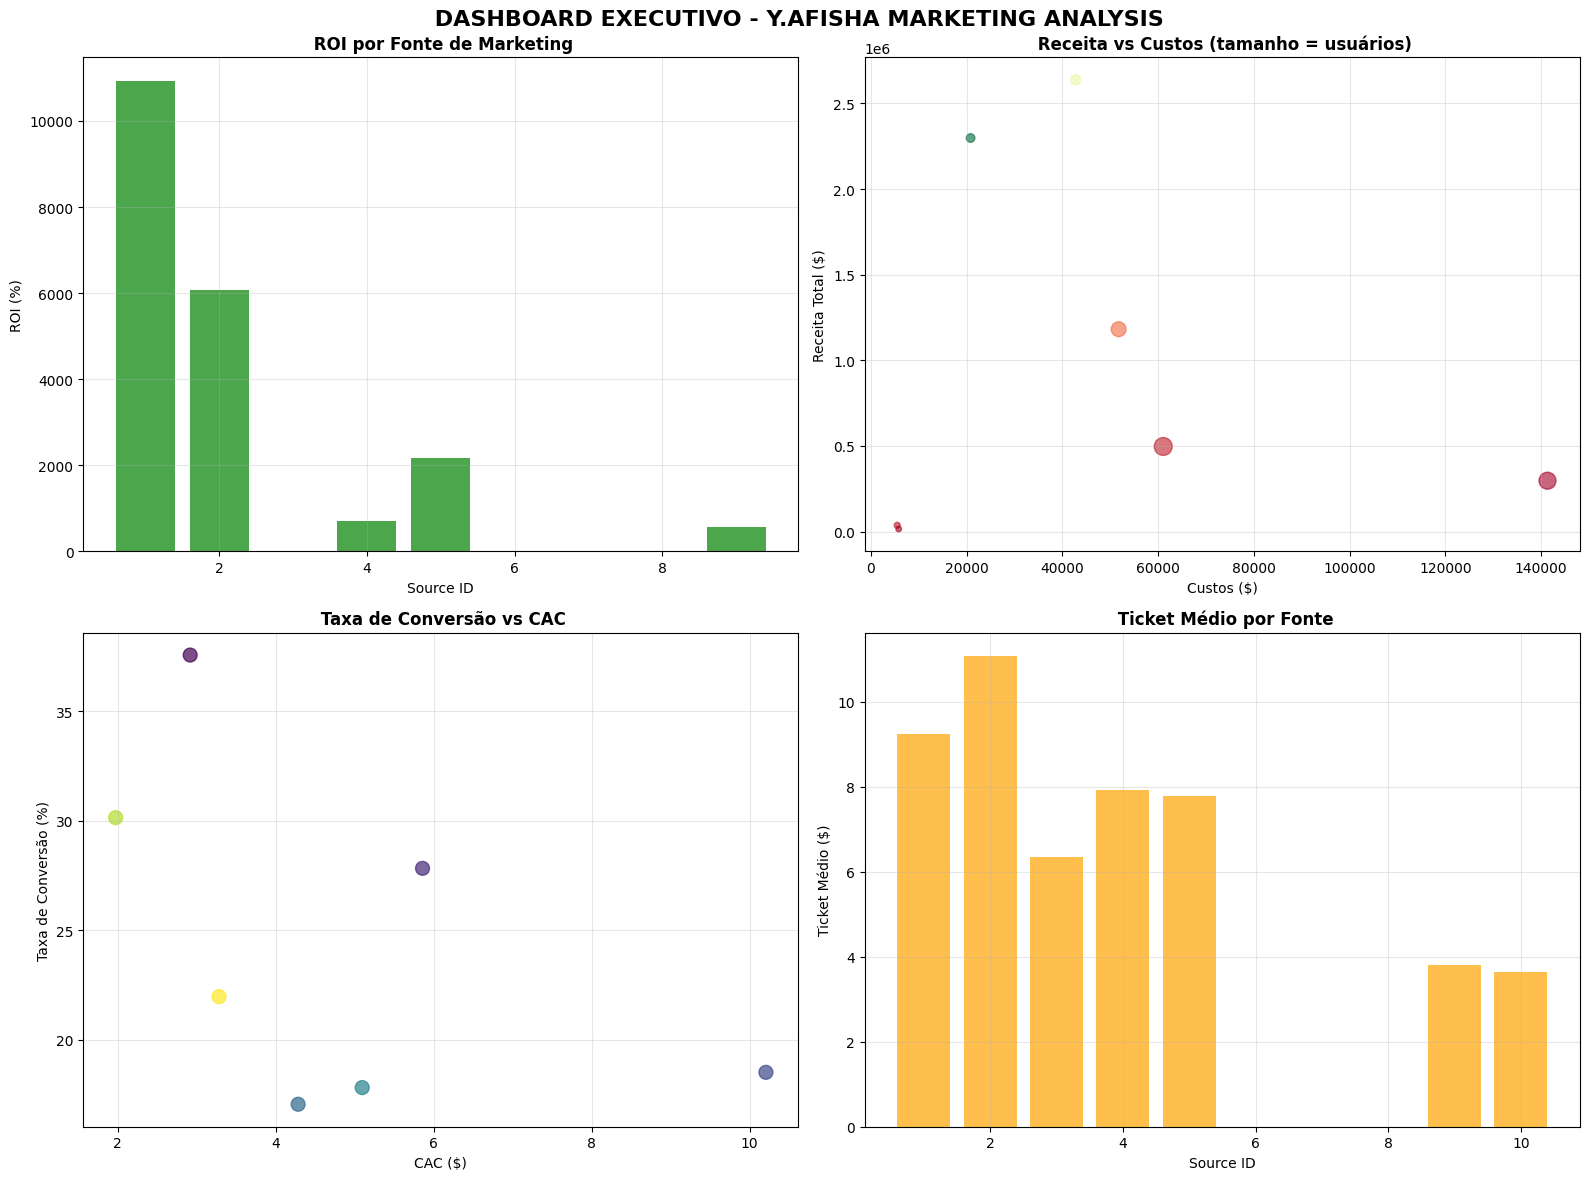

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
plt.style.use('default')
sns.set_palette("husl")

# 1. Dashboard Executivo - 4 gráficos principais
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' DASHBOARD EXECUTIVO - Y.AFISHA MARKETING ANALYSIS', fontsize=16, fontweight='bold')

# Gráfico 1: ROI por Fonte
top_sources = tabela_final.head(5)
ax1.bar(top_sources['source_id'], top_sources['roi'], color='green', alpha=0.7)
ax1.set_title(' ROI por Fonte de Marketing', fontweight='bold')
ax1.set_xlabel('Source ID')
ax1.set_ylabel('ROI (%)')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Receita vs Custos
ax2.scatter(tabela_final['costs'], tabela_final['total_revenue'], 
           s=tabela_final['total_usuarios']/500, alpha=0.6, c=tabela_final['roi'], cmap='RdYlGn')
ax2.set_title(' Receita vs Custos (tamanho = usuários)', fontweight='bold')
ax2.set_xlabel('Custos ($)')
ax2.set_ylabel('Receita Total ($)')
ax2.grid(True, alpha=0.3)

# Gráfico 3: Taxa de Conversão vs CAC
ax3.scatter(tabela_final['CAC'], tabela_final['taxa_conversao'], 
           s=100, alpha=0.7, c=tabela_final['source_id'], cmap='viridis')
ax3.set_title(' Taxa de Conversão vs CAC', fontweight='bold')
ax3.set_xlabel('CAC ($)')
ax3.set_ylabel('Taxa de Conversão (%)')
ax3.grid(True, alpha=0.3)

# Gráfico 4: Ticket Médio por Fonte
ax4.bar(tabela_final['source_id'], tabela_final['avg_ticket'], color='orange', alpha=0.7)
ax4.set_title(' Ticket Médio por Fonte', fontweight='bold')
ax4.set_xlabel('Source ID')
ax4.set_ylabel('Ticket Médio ($)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Principais Descobertas
#Fonte 1 – Eficiência Máxima

#ROI de 10.931% e CAC baixo (R$ 2,92).

#Conversão alta (37,57%).

#É o canal mais eficiente em transformar investimento em receita.

#Fonte 2 – Escala Máxima

#Receita total mais alta (≈ R$ 2,63 milhões).

#ROI de 6.063%, CAC moderado (R$ 5,86).

#Apesar de menor eficiência que a Fonte 1, garante maior volume absoluto de vendas.

#Fonte 3 – O dilema do volume

#Maior investimento (R$ 141 mil) e muitos usuários (74 mil).

#ROI baixo (110%) e CAC alto (R$ 10,21).

#Mostra que quantidade não significa qualidade: muitos visitantes, mas baixo valor por cliente.

#Recomendações Estratégicas
#Priorizar investimento em Fonte 1 (eficiência) e Fonte 2 (escala).
#Manter Fonte 5 como apoio, já que apresenta ROI sólido (2.183%).
#Reduzir ou otimizar investimento em Fonte 3 e 4, que têm volume mas baixa eficiência.
#Descontinuar Fontes 7 e 10, irrelevantes para a estratégia.
#Fonte 9 pode ser mantida como canal de teste/otimização: CAC muito baixo, mas receita limitada.
#Conclusão
#A análise mostra claramente o dilema estratégico:
#Fonte 1 representa eficiência máxima (ROI altíssimo).
#Fonte 2 representa escala máxima (maior receita absoluta).
#A estratégia recomendada é equilibrar eficiência e escala, aumentando investimento nas Fontes 1 e 2, mantendo Fonte 5 como suporte, e cortando canais pouco rentáveis.

#Uma estratégia equilibrada poderia ser:

#40% em Fonte 1 → garantir máxima eficiência e aproveitar todo o potencial desse canal.

#60% em Fonte 2 → sustentar escala e crescimento, mesmo com ROI menor.

#Alternativamente, se o objetivo da empresa for maximizar lucro líquido, poderia inverter para 60% Fonte 1 / 40% Fonte 2.
#Mas se o objetivo for crescimento agressivo, manter 70% Fonte 2 / 30% Fonte 1 seria mais adequado.

#Como testar os limites de escala da Fonte 1
#Incrementos graduais: aumentar o orçamento em pequenos passos (ex.: +10% por mês).

#Monitorar ROI e CAC: verificar se a eficiência se mantém ou começa a cair.

#Segmentação: testar diferentes públicos dentro da mesma fonte para ver se há novos nichos ainda não explorados.

#A/B testing: rodar campanhas paralelas com diferentes criativos para medir se o ROI se sustenta.

#Se o ROI cair significativamente ao aumentar o investimento, isso confirma que a fonte atingiu seu limite de escala.

#Conclusão estratégica
#Fonte 1 → manter como canal premium de eficiência, mas testar cuidadosamente sua escalabilidade.

#Fonte 2 → principal motor de crescimento, absorve a maior parte do orçamento.

#Estratégia final → equilíbrio entre eficiência e escala, com ajustes dinâmicos conforme os testes revelarem o teto de Fonte 1.

A Y.Afisha deve adotar uma estratégia híbrida:

Fonte 1 como canal premium de eficiência.

#Fonte 2 como motor principal de crescimento.

#Fonte 5 como suporte estratégico.

#Cortar canais pouco rentáveis e manter Fonte 9 como laboratório de otimização.

#Essa combinação garante lucro líquido elevado e crescimento sustentável, equilibrando o dilema clássico entre eficiência e escala.